# RCEW GEDI Waveform, Quality-Flag, and AOI Diagnostic

This notebook applies the same GEDI diagnostic and Gaussian-decomposition workflow used for the NCA to the **spatial-only RCEW GEDI L1B/L2A subsets**.

RCEW is deliberately treated as a comparative landscape rather than as an interchangeable replicate of the NCA. Relative to the flatter, short-stature NCA, RCEW provides substantially greater terrain relief, slope, and vertical vegetation structure. The workflow therefore remains identical where possible so that differences in waveform morphology, detected mode number, Gaussian component structure, pulse width, amplitude, and near-ground energy can be attributed to the landscapes rather than to different processing pipelines.

The objectives are to:

1. inventory the RCEW subset archive and confirm L1B/L2A pairing,
2. inspect available beam-level and shot-level science datasets,
3. summarize GEDI quality/degradation flags **before filtering**,
4. pair L1B and L2A records by `shot_number`,
5. examine AOI-scale spatial coverage and beam representation,
6. quantify coordinate and elevation consistency diagnostics,
7. inspect full receive/transmit waveforms,
8. apply the same retained-shot quality criterion used for the NCA,
9. characterize RH distributions and waveform morphology,
10. compare GEDI `num_detectedmodes` with an independent peak-detection / constrained Gaussian-decomposition workflow.

No quality filter is imposed during the initial archive inspection. The retained science subset is created later in memory so that filtering effects remain explicit and auditable.

### Comparative principle

The NCA and RCEW notebooks should differ in **data**, not in analytical definitions. In particular, the same quality rules, peak-detection settings, Gaussian constraints, waveform summaries, and diagnostics should initially be used in both AOIs. Any subsequent AOI-specific parameter changes should be justified by observed measurement behavior rather than tuned simply to make the landscapes agree.


In [1]:
from pathlib import Path
import re
import warnings

import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

warnings.filterwarnings("ignore", category=RuntimeWarning)


## 1. Paths and configuration


In [2]:
# =============================================================================
# RCEW paths and configuration
# =============================================================================

SUBSET_ROOT = Path(
    r"A:\RCEW_DATA\Ancillary_Data\GEDI"
    r"\RCEW_template_bbox_L1B_L2A"
    r"\RCEW_spatial_subset_h5"
)

# Retained subset products
L1B_DIR = SUBSET_ROOT / "GEDI01_B"
L2A_DIR = SUBSET_ROOT / "GEDI02_A"

# RCEW analysis boundary
AOI_PATH = Path(
    r"A:\RCEW_DATA\Templates"
    r"\RCEW_shapefile"
    r"\RCEW_extent_26911.shp"
)

# Number of example waveforms to plot per diagnostic class.
N_WAVEFORMS_PER_CLASS = 4

# Reproducible sampling.
RANDOM_SEED = 42

print("Subset root:", SUBSET_ROOT)
print("L1B subset:", L1B_DIR)
print("L2A subset:", L2A_DIR)
print("AOI:", AOI_PATH)

assert SUBSET_ROOT.exists(), f"Missing subset root: {SUBSET_ROOT}"
assert L1B_DIR.exists(), f"Missing L1B subset directory: {L1B_DIR}"
assert L2A_DIR.exists(), f"Missing L2A subset directory: {L2A_DIR}"
assert AOI_PATH.exists(), f"Missing AOI: {AOI_PATH}"


Subset root: A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\RCEW_spatial_subset_h5
L1B subset: A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\RCEW_spatial_subset_h5\GEDI01_B
L2A subset: A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\RCEW_spatial_subset_h5\GEDI02_A
AOI: A:\RCEW_DATA\Templates\RCEW_shapefile\RCEW_extent_26911.shp


## 2. Pair L1B and L2A subset granules

The repacker preserved paired granules using the shared orbit/sub-orbit key:

`O#####_##_T#####_##`

We first verify that the analytical subset archive still has one-to-one L1B/L2A pairing.


In [3]:
ORBIT_KEY_RE = re.compile(r"(O\d{5}_\d{2}_T\d{5}_\d{2})")

def orbit_key(path_or_name):
    name = Path(path_or_name).name
    m = ORBIT_KEY_RE.search(name)
    if m is None:
        raise ValueError(f"Could not parse GEDI orbit key: {name}")
    return m.group(1)

l1b_files = sorted(L1B_DIR.glob("*.h5"))
l2a_files = sorted(L2A_DIR.glob("*.h5"))

l1b_lookup = {orbit_key(p): p for p in l1b_files}
l2a_lookup = {orbit_key(p): p for p in l2a_files}

all_keys = sorted(set(l1b_lookup) | set(l2a_lookup))

pair_table = pd.DataFrame({
    "granule_key": all_keys,
    "l1b": [l1b_lookup.get(k) for k in all_keys],
    "l2a": [l2a_lookup.get(k) for k in all_keys],
})
pair_table["paired"] = pair_table["l1b"].notna() & pair_table["l2a"].notna()

print(f"L1B subset files: {len(l1b_files):,}")
print(f"L2A subset files: {len(l2a_files):,}")
print(f"Paired granules:  {pair_table['paired'].sum():,}")
print(f"Unpaired records: {(~pair_table['paired']).sum():,}")

display(pair_table.head(20))

if not pair_table["paired"].all():
    display(pair_table.loc[~pair_table["paired"]])


L1B subset files: 67
L2A subset files: 67
Paired granules:  67
Unpaired records: 0


,granule_key,l1b,l2a,paired
0,O02489_02_T00140_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True
1,O02523_03_T02408_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True
2,O02657_02_T05679_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True
3,O02920_03_T05407_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True
4,O03054_02_T01716_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True
5,O03317_03_T03831_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True
6,O03451_02_T04103_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True
7,O03680_02_T02986_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True
8,O03909_02_T01410_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True
9,O04611_02_T04409_02,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template...,True


## 3. Generic HDF5 structure helpers

GEDI is hierarchical and some variables differ slightly in location among products/releases.  
These helpers:

- list beams,
- recursively inventory datasets,
- locate the first available candidate dataset,
- read only shot-oriented 1-D vectors when lengths match `shot_number`.

This keeps the diagnostic tolerant to small path differences without silently coercing incompatible arrays.


In [4]:
BEAM_RE = re.compile(r"^BEAM\d{4}$")

def list_beams(h5):
    return sorted(k for k in h5.keys() if BEAM_RE.match(k))

def walk_datasets(group, prefix=""):
    rows = []
    for name, obj in group.items():
        path = f"{prefix}/{name}" if prefix else name
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "path": path,
                "shape": obj.shape,
                "dtype": str(obj.dtype),
            })
        elif isinstance(obj, h5py.Group):
            rows.extend(walk_datasets(obj, path))
    return rows

def first_existing(group, candidates):
    for path in candidates:
        try:
            obj = group[path]
            if isinstance(obj, h5py.Dataset):
                return obj, path
        except Exception:
            pass
    return None, None

def read_1d(group, candidates, n=None):
    ds, used = first_existing(group, candidates)
    if ds is None:
        return None, None
    arr = np.asarray(ds)
    if arr.ndim != 1:
        return None, used
    if n is not None and len(arr) != n:
        return None, used
    return arr, used

def safe_numeric(arr):
    if arr is None:
        return None
    arr = np.asarray(arr)
    if arr.dtype.kind in "biufc":
        return arr
    return None


## 4. Inspect the structure of one paired granule


In [5]:
paired = pair_table.loc[pair_table["paired"]].reset_index(drop=True)
if paired.empty:
    raise RuntimeError("No paired subset granules found.")

example_l1b = paired.loc[0, "l1b"]
example_l2a = paired.loc[0, "l2a"]

print("Example L1B:", example_l1b.name)
print("Example L2A:", example_l2a.name)

with h5py.File(example_l1b, "r") as h5:
    print("\nL1B beams:", list_beams(h5))
    l1b_inventory = pd.DataFrame(walk_datasets(h5))

with h5py.File(example_l2a, "r") as h5:
    print("L2A beams:", list_beams(h5))
    l2a_inventory = pd.DataFrame(walk_datasets(h5))

print("\nL1B dataset inventory:")
display(l1b_inventory.head(100))

print("\nL2A dataset inventory:")
display(l2a_inventory.head(100))


Example L1B: GEDI01_B_2019142030259_O02489_02_T00140_02_005_01_V002.h5
Example L2A: GEDI02_A_2019142030259_O02489_02_T00140_02_003_01_V002.h5

L1B beams: ['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']
L2A beams: ['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']

L1B dataset inventory:


,path,shape,dtype
0,BEAM0000/all_samples_sum,"(230,)",uint32
1,BEAM0000/ancillary/master_time_epoch,"(1,)",float64
2,BEAM0000/ancillary/mean_samples,"(1,)",int64
3,BEAM0000/ancillary/smoothing_width,"(1,)",float64
4,BEAM0000/beam,"(230,)",uint16
5,BEAM0000/channel,"(230,)",uint8
6,BEAM0000/delta_time,"(230,)",float64
7,BEAM0000/geolocation/altitude_instrument,"(230,)",float64
8,BEAM0000/geolocation/altitude_instrument_error,"(230,)",float32
9,BEAM0000/geolocation/bounce_time_offset_bin0,"(230,)",float64



L2A dataset inventory:


,path,shape,dtype
0,BEAM0000/ancillary/l2a_alg_count,"(1,)",uint8
1,BEAM0000/beam,"(230,)",uint16
2,BEAM0000/channel,"(230,)",uint8
3,BEAM0000/degrade_flag,"(230,)",uint8
4,BEAM0000/delta_time,"(230,)",float64
5,BEAM0000/digital_elevation_model,"(230,)",float32
6,BEAM0000/digital_elevation_model_srtm,"(230,)",float32
7,BEAM0000/elev_highestreturn,"(230,)",float32
8,BEAM0000/elev_lowestmode,"(230,)",float32
9,BEAM0000/elevation_bias_flag,"(230,)",uint8


## 5. Extract AOI shot tables from every subset file

The L2A table is the main science/quality table.  
The L1B table provides waveform indexing and independent product-coordinate fields.

Candidate fields are read only when they are present and shot-aligned.


In [9]:
L2A_FIELDS = {
    "latitude_l2a": ["lat_lowestmode", "geolocation/latitude_lowestmode", "geolocation/lat_lowestmode"],
    "longitude_l2a": ["lon_lowestmode", "geolocation/longitude_lowestmode", "geolocation/lon_lowestmode"],
    "quality_flag": ["quality_flag"],
    "degrade_flag": ["degrade_flag", "geolocation/degrade_flag"],
    "sensitivity": ["sensitivity"],
    "surface_flag": ["surface_flag"],
    "elevation_bias_flag": ["elevation_bias_flag"],
    "selected_algorithm": ["selected_algorithm"],
    "selected_mode": ["selected_mode"],
    "selected_mode_flag": ["selected_mode_flag"],
    "num_detectedmodes": ["num_detectedmodes"],
    "elev_lowestmode": ["elev_lowestmode"],
    "elev_highestreturn": ["elev_highestreturn"],
    "digital_elevation_model": ["digital_elevation_model", "geolocation/digital_elevation_model"],
    "solar_elevation": ["solar_elevation", "geolocation/solar_elevation"],
    "delta_time": ["delta_time"],
    "beam_type": ["beam_type", "geolocation/beam_type"],
    "channel": ["channel", "geolocation/channel"],
}

L1B_FIELDS = {
    "latitude_l1b": ["geolocation/latitude_bin0", "latitude_bin0"],
    "longitude_l1b": ["geolocation/longitude_bin0", "longitude_bin0"],
    "elevation_bin0": ["geolocation/elevation_bin0", "elevation_bin0"],
    "elevation_lastbin": ["geolocation/elevation_lastbin", "elevation_lastbin"],
    "digital_elevation_model_l1b": ["geolocation/digital_elevation_model", "digital_elevation_model"],
    "degrade_flag_l1b": ["geolocation/degrade_flag", "degrade_flag"],
    "geolocation_quality_flag": ["geolocation/quality_flag"],
    "stale_return_flag": ["stale_return_flag"],
    "rx_sample_start_index": ["rx_sample_start_index"],
    "rx_sample_count": ["rx_sample_count"],
    "tx_sample_start_index": ["tx_sample_start_index"],
    "tx_sample_count": ["tx_sample_count"],
    "rx_energy": ["rx_energy"],
    "tx_energy": ["tx_energy"],
    "rx_maxamp": ["rx_maxamp"],
    "rx_mean": ["rx_mean"],
    "rx_sd": ["rx_sd"],
    "noise_mean_corrected": ["noise_mean_corrected"],
}

def extract_shot_table(path, level):
    fields = L2A_FIELDS if level == "L2A" else L1B_FIELDS
    parts = []

    with h5py.File(path, "r") as h5:
        for beam in list_beams(h5):
            g = h5[beam]

            shot, shot_path = read_1d(g, ["shot_number", "geolocation/shot_number"])
            if shot is None:
                continue

            n = len(shot)
            out = {
                "granule_key": np.repeat(orbit_key(path), n),
                "source_file": np.repeat(path.name, n),
                "level": np.repeat(level, n),
                "beam": np.repeat(beam, n),
                # preserve exact integer identity
                "shot_number": shot.astype(np.uint64),
            }

            for col, candidates in fields.items():
                arr, _ = read_1d(g, candidates, n=n)
                if arr is not None:
                    out[col] = arr

            parts.append(pd.DataFrame(out))

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def build_product_table(paths, level):
    parts = []
    failed = []

    for i, p in enumerate(paths, 1):
        try:
            df = extract_shot_table(p, level)
            if not df.empty:
                parts.append(df)
        except Exception as exc:
            failed.append((p.name, repr(exc)))

        if i % 25 == 0 or i == len(paths):
            print(f"{level}: {i:,}/{len(paths):,} files scanned")

    if failed:
        print(f"\n{level}: {len(failed)} failed files")
        display(pd.DataFrame(failed, columns=["file", "error"]).head(20))

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

l2a = build_product_table(l2a_files, "L2A")
l1b = build_product_table(l1b_files, "L1B")

print("\nL2A shots:", f"{len(l2a):,}")
print("L1B shots:", f"{len(l1b):,}")

print("\nL2A columns:")
print(sorted(l2a.columns))

print("\nL1B columns:")
print(sorted(l1b.columns))


L2A: 25/67 files scanned
L2A: 50/67 files scanned
L2A: 67/67 files scanned
L1B: 25/67 files scanned
L1B: 50/67 files scanned
L1B: 67/67 files scanned

L2A shots: 71,100
L1B shots: 71,100

L2A columns:
['beam', 'channel', 'degrade_flag', 'delta_time', 'digital_elevation_model', 'elev_highestreturn', 'elev_lowestmode', 'elevation_bias_flag', 'granule_key', 'latitude_l2a', 'level', 'longitude_l2a', 'num_detectedmodes', 'quality_flag', 'selected_algorithm', 'selected_mode', 'selected_mode_flag', 'sensitivity', 'shot_number', 'solar_elevation', 'source_file', 'surface_flag']

L1B columns:
['beam', 'digital_elevation_model_l1b', 'elevation_bin0', 'elevation_lastbin', 'granule_key', 'latitude_l1b', 'level', 'longitude_l1b', 'noise_mean_corrected', 'rx_energy', 'rx_sample_count', 'rx_sample_start_index', 'shot_number', 'source_file', 'stale_return_flag', 'tx_sample_count', 'tx_sample_start_index']


## 6. Pair shot-level L1B and L2A records

`shot_number` plus `beam` is used as the scientific join key.  
The join is validated rather than assumed.


In [10]:
join_cols = ["granule_key", "beam", "shot_number"]

dup_l2a = l2a.duplicated(join_cols).sum()
dup_l1b = l1b.duplicated(join_cols).sum()

print("Duplicate L2A join keys:", f"{dup_l2a:,}")
print("Duplicate L1B join keys:", f"{dup_l1b:,}")

if dup_l2a or dup_l1b:
    raise ValueError("Duplicate shot keys detected; inspect before merging.")

shots = l2a.merge(
    l1b.drop(columns=["level"], errors="ignore"),
    on=join_cols,
    how="outer",
    suffixes=("_l2a_src", "_l1b_src"),
    indicator=True,
    validate="one_to_one",
)

print(shots["_merge"].value_counts(dropna=False))
print(f"\nExactly paired shots: {(shots['_merge'] == 'both').sum():,}")
print(f"Total unique shots:   {len(shots):,}")

paired_shots = shots.loc[shots["_merge"].eq("both")].copy()


Duplicate L2A join keys: 0
Duplicate L1B join keys: 0
_merge
both          71100
left_only         0
right_only        0
Name: count, dtype: int64

Exactly paired shots: 71,100
Total unique shots:   71,100


## 7. Quality/degradation flag census

Do **not** collapse `degrade_flag` to `== 0` yet.

GEDI V2 workflows often use `quality_flag == 1` and then evaluate degradation/sensitivity criteria, but degradation codes contain more information than a binary good/bad distinction. We first inspect the codes actually present in the RCEW.


In [11]:
def frequency_table(df, col):
    if col not in df.columns:
        print(f"{col}: not present")
        return pd.DataFrame()

    x = df[col]
    out = (
        x.value_counts(dropna=False)
         .rename("n")
         .to_frame()
         .assign(percent=lambda d: 100 * d["n"] / d["n"].sum())
         .reset_index()
         .rename(columns={"index": col})
    )
    return out

for col in [
    "quality_flag",
    "degrade_flag",
    "surface_flag",
    "elevation_bias_flag",
    "selected_algorithm",
    "selected_mode_flag",
    "num_detectedmodes",
    "geolocation_quality_flag",
    "stale_return_flag",
]:
    print(f"\n{col}")
    display(frequency_table(paired_shots, col))



quality_flag


,quality_flag,n,percent
0,0,37093,52.170183
1,1,34007,47.829817



degrade_flag


,degrade_flag,n,percent
0,0,51837,72.907173
1,70,6424,9.035162
2,30,4883,6.867792
3,80,4567,6.423347
4,50,3012,4.236287
5,4,377,0.530239



surface_flag


...

,num_detectedmodes,n,percent
0,1,48337,67.984529
1,0,19503,27.430380
2,2,2262,3.181435
3,3,596,0.838256
4,4,245,0.344585
5,5,107,0.150492
6,6,28,0.039381
7,7,11,0.015471
8,8,8,0.011252
9,9,3,0.004219



geolocation_quality_flag
geolocation_quality_flag: not present


""



stale_return_flag


,stale_return_flag,n,percent
0,0,52784,74.2391
1,1,18316,25.7609


## 8. Cross-tabulate quality versus degradation and beam

This tells us whether "bad" flags are concentrated in particular beams or degradation classes rather than evenly distributed.


In [12]:
if {"quality_flag", "degrade_flag"}.issubset(paired_shots.columns):
    q_by_deg = pd.crosstab(
        paired_shots["degrade_flag"],
        paired_shots["quality_flag"],
        margins=True,
        normalize="index",
    )
    print("Row proportions: quality_flag conditional on degrade_flag")
    display(q_by_deg)

if "quality_flag" in paired_shots.columns:
    q_by_beam = pd.crosstab(
        paired_shots["beam"],
        paired_shots["quality_flag"],
        margins=True,
    )
    print("\nCounts by beam")
    display(q_by_beam)


Row proportions: quality_flag conditional on degrade_flag


quality_flag,0,1
degrade_flag,,
0,0.495515,0.504485
4,0.997347,0.002653
30,0.624616,0.375384
50,0.508300,0.491700
70,0.531133,0.468867
80,0.665207,0.334793
All,0.521702,0.478298



Counts by beam


quality_flag,0,1,All
beam,,,
BEAM0000,6993,1732,8725
BEAM0001,6658,2013,8671
BEAM0010,5879,2773,8652
BEAM0011,5273,3399,8672
BEAM0101,2920,5920,8840
BEAM0110,2961,5882,8843
BEAM1000,3221,6113,9334
BEAM1011,3188,6175,9363
All,37093,34007,71100


## 9. Sensitivity distributions

Sensitivity is examined continuously rather than immediately thresholded.

For this AOI, a threshold decision should be justified by how waveform morphology and elevation/height diagnostics change across the observed sensitivity distribution.


,sensitivity
count,71100.000000
mean,1.227074
std,117.205635
min,-8418.443359
1%,-9.137339
5%,-0.963463
10%,0.201694
25%,0.859182
50%,0.923080
75%,0.959687


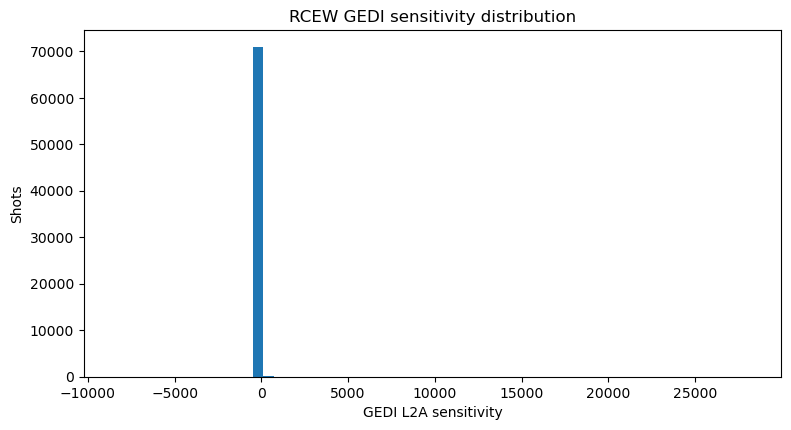

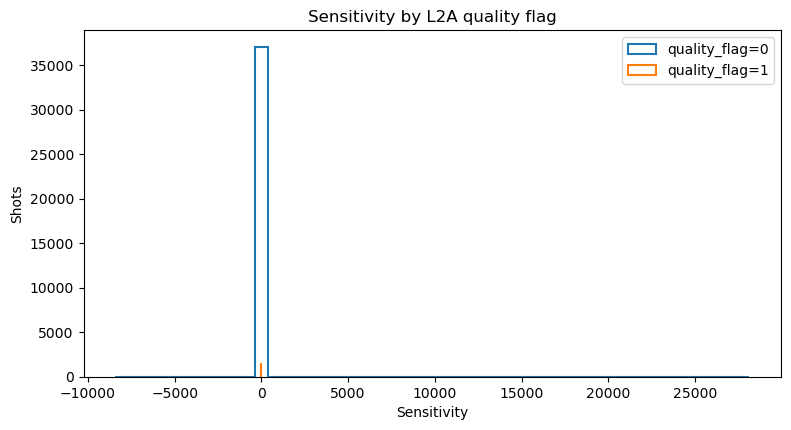

In [13]:
if "sensitivity" in paired_shots.columns:
    s = pd.to_numeric(paired_shots["sensitivity"], errors="coerce")
    display(s.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("sensitivity"))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(s.dropna(), bins=60)
    ax.set_xlabel("GEDI L2A sensitivity")
    ax.set_ylabel("Shots")
    ax.set_title("RCEW GEDI sensitivity distribution")
    plt.show()

    if "quality_flag" in paired_shots.columns:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        for flag, sub in paired_shots.groupby("quality_flag", dropna=False):
            vals = pd.to_numeric(sub["sensitivity"], errors="coerce").dropna()
            if len(vals):
                ax.hist(vals, bins=50, histtype="step", linewidth=1.5, label=f"quality_flag={flag}")
        ax.set_xlabel("Sensitivity")
        ax.set_ylabel("Shots")
        ax.set_title("Sensitivity by L2A quality flag")
        ax.legend()
        plt.show()


## 10. AOI coverage and beam representation

This is a coverage diagnostic, not a density-corrected ecological sample design.

We visualize:

- all retained L2A shot centers,
- the AOI boundary,
- spatial patterns of `quality_flag` where available.

Persistent spatial gaps or flag clusters are more consequential than a single archive-wide percentage.


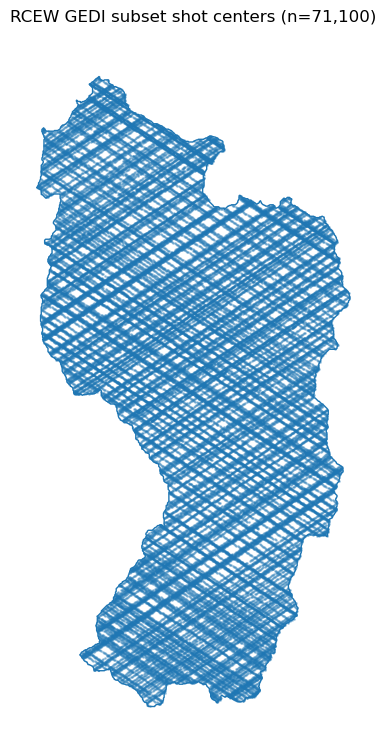

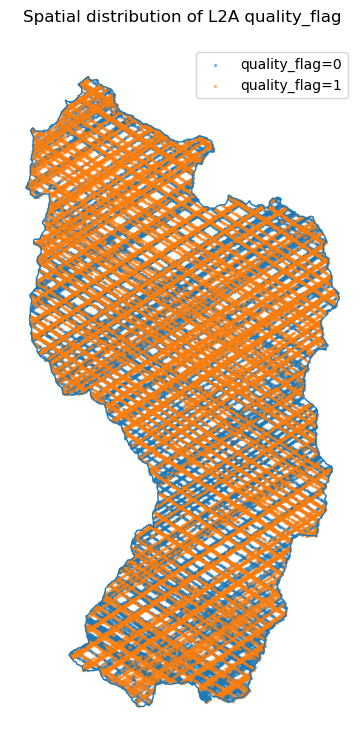

,shots
beam,
BEAM1011,9363
BEAM1000,9334
BEAM0110,8843
BEAM0101,8840
BEAM0000,8725
BEAM0011,8672
BEAM0001,8671
BEAM0010,8652


In [14]:
aoi = gpd.read_file(AOI_PATH)

if aoi.crs is None:
    raise ValueError("AOI has no CRS.")

if {"longitude_l2a", "latitude_l2a"}.issubset(paired_shots.columns):
    xy = paired_shots.dropna(subset=["longitude_l2a", "latitude_l2a"]).copy()

    shot_gdf = gpd.GeoDataFrame(
        xy,
        geometry=gpd.points_from_xy(xy["longitude_l2a"], xy["latitude_l2a"]),
        crs="EPSG:4326",
    ).to_crs(aoi.crs)

    fig, ax = plt.subplots(figsize=(9, 9))
    aoi.boundary.plot(ax=ax, linewidth=1)
    shot_gdf.plot(ax=ax, markersize=1, alpha=0.35)
    ax.set_title(f"RCEW GEDI subset shot centers (n={len(shot_gdf):,})")
    ax.set_axis_off()
    plt.show()

    if "quality_flag" in shot_gdf.columns:
        fig, ax = plt.subplots(figsize=(9, 9))
        aoi.boundary.plot(ax=ax, linewidth=1)
        for flag, sub in shot_gdf.groupby("quality_flag", dropna=False):
            sub.plot(ax=ax, markersize=2, alpha=0.45, label=f"quality_flag={flag}")
        ax.set_title("Spatial distribution of L2A quality_flag")
        ax.set_axis_off()
        ax.legend()
        plt.show()

    beam_counts = (
        shot_gdf.groupby("beam")
        .size()
        .rename("shots")
        .sort_values(ascending=False)
        .to_frame()
    )
    display(beam_counts)
else:
    print("L2A longitude/latitude fields were not available.")


## 11. Horizontal L1B↔L2A coordinate consistency

For the same `shot_number`, compare:

- L1B `geolocation/latitude_bin0`, `longitude_bin0`
- L2A `lat_lowestmode`, `lon_lowestmode`

This is **not external geolocation accuracy** because the products are related.  
It is a useful internal consistency diagnostic and can expose gross mismatches, repacking errors, or unusual processing cases.

Distance is calculated with a haversine approximation.


,L1B-L2A horizontal offset (m)
count,71100.000000
mean,1.678019
std,1.668671
min,0.000000
50%,1.279102
90%,4.167106
95%,4.782966
99%,6.029022
99.9%,9.979376
max,15.261934


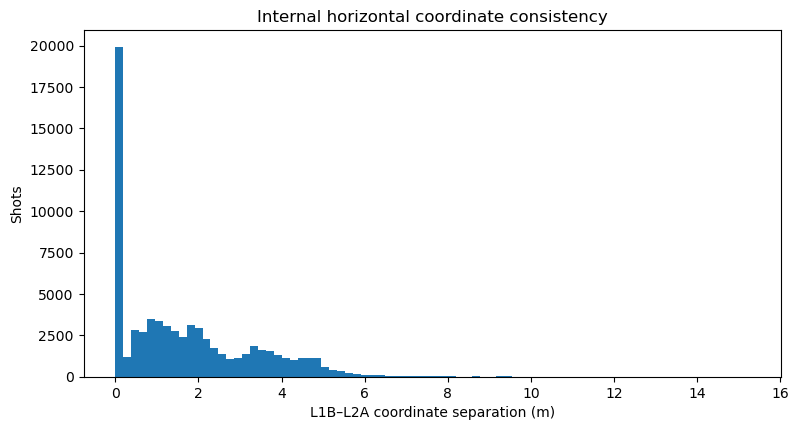


Largest coordinate disagreements:


,granule_key,beam,shot_number,l1b_l2a_horizontal_offset_m,quality_flag,degrade_flag,sensitivity
47672,O20873_03_T10946_02,BEAM1000,208730800300245624,15.261934,0,80,0.965404
46236,O20873_03_T10946_02,BEAM0000,208730000300245897,14.744043,0,80,0.878076
46245,O20873_03_T10946_02,BEAM0000,208730000300245906,14.677531,0,80,0.896651
46317,O20873_03_T10946_02,BEAM0001,208730100300241868,14.606478,0,80,0.852255
65930,O32130_02_T01716_02,BEAM1000,321300800200105188,14.509485,0,0,0.964758
46481,O20873_03_T10946_02,BEAM0001,208730100300242032,14.495058,0,80,0.847940
46315,O20873_03_T10946_02,BEAM0001,208730100300241866,14.488960,0,80,0.883693
46488,O20873_03_T10946_02,BEAM0001,208730100300242039,14.465523,0,80,0.861399
64944,O32130_02_T01716_02,BEAM0001,321300100200100060,14.045361,1,0,0.905001
65115,O32130_02_T01716_02,BEAM0010,321300200200105003,13.900268,0,0,0.923023


In [15]:
EARTH_RADIUS_M = 6_371_008.8

def haversine_m(lon1, lat1, lon2, lat2):
    lon1 = np.radians(np.asarray(lon1, dtype=float))
    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon2 = np.radians(np.asarray(lon2, dtype=float))
    lat2 = np.radians(np.asarray(lat2, dtype=float))

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * EARTH_RADIUS_M * np.arcsin(np.sqrt(a))

coord_cols = {
    "longitude_l1b", "latitude_l1b",
    "longitude_l2a", "latitude_l2a",
}

if coord_cols.issubset(paired_shots.columns):
    valid = paired_shots[list(coord_cols)].notna().all(axis=1)

    paired_shots.loc[valid, "l1b_l2a_horizontal_offset_m"] = haversine_m(
        paired_shots.loc[valid, "longitude_l1b"],
        paired_shots.loc[valid, "latitude_l1b"],
        paired_shots.loc[valid, "longitude_l2a"],
        paired_shots.loc[valid, "latitude_l2a"],
    )

    off = paired_shots["l1b_l2a_horizontal_offset_m"].dropna()

    display(
        off.describe(
            percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
        ).to_frame("L1B-L2A horizontal offset (m)")
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(off, bins=80)
    ax.set_xlabel("L1B–L2A coordinate separation (m)")
    ax.set_ylabel("Shots")
    ax.set_title("Internal horizontal coordinate consistency")
    plt.show()

    print("\nLargest coordinate disagreements:")
    display(
        paired_shots.nlargest(
            20, "l1b_l2a_horizontal_offset_m"
        )[
            [
                "granule_key", "beam", "shot_number",
                "l1b_l2a_horizontal_offset_m",
                "quality_flag", "degrade_flag", "sensitivity"
            ]
        ]
    )
else:
    print("Required L1B/L2A coordinate fields are not all present.")


## 12. Elevation / DEM consistency

The most useful AOI-scale elevation residual is:

\[
r_{DEM} = z_{\mathrm{GEDI,\ lowestmode}} - z_{\mathrm{reference\ DEM}}
\]

This is not automatically an error term: GEDI's lowest detected return and the raster DEM do not represent precisely the same spatial/vertical support.

Use this to find structure, tails, flag associations, and implausible cases—not as an unquestioned rejection criterion.


,elev_lowestmode - DEM (m)
count,71100.000000
mean,-274.576935
std,7186.395020
min,-70376.914062
1%,-64007.377891
5%,-24.937421
50%,1.263733
95%,4472.860083
99%,5875.802627
max,8030.724609


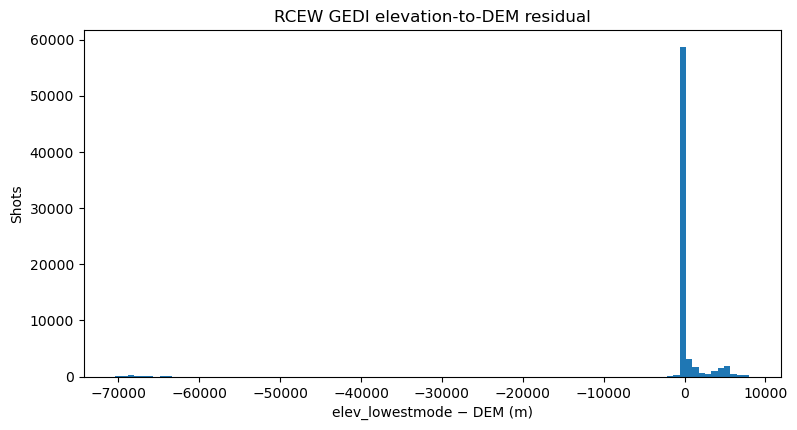

,count,median,mean,std
quality_flag,,,,
0,37093,6.110596,-526.507446,9942.853516
1,34007,-0.107178,0.215215,13.407060


Largest absolute residuals:


,granule_key,beam,shot_number,elev_lowestmode,digital_elevation_model,lowestmode_minus_dem_m,surface_flag,quality_flag,degrade_flag,sensitivity
71031,O33705_03_T09217_02,BEAM1000,337050800300243596,-68163.390625,2213.525391,-70376.914062,0,0,50,-22.103458
71030,O33705_03_T09217_02,BEAM1000,337050800300243595,-68162.828125,2213.525391,-70376.351562,0,0,50,3.660929
71032,O33705_03_T09217_02,BEAM1000,337050800300243597,-68163.109375,2200.720947,-70363.828125,0,0,50,0.127960
71033,O33705_03_T09217_02,BEAM1000,337050800300243598,-68163.796875,2190.296143,-70354.093750,0,0,50,-23.524094
71035,O33705_03_T09217_02,BEAM1000,337050800300243600,-68163.796875,2182.117676,-70345.914062,0,0,50,0.456291
71054,O33705_03_T09217_02,BEAM1000,337050800300243623,-68165.921875,2179.363770,-70345.289062,0,0,50,2.274731
71034,O33705_03_T09217_02,BEAM1000,337050800300243599,-68163.062500,2180.762939,-70343.828125,0,0,50,1.698146
71053,O33705_03_T09217_02,BEAM1000,337050800300243618,-68164.968750,2177.351807,-70342.320312,0,0,50,0.046114
71057,O33705_03_T09217_02,BEAM1000,337050800300243626,-68165.882812,2174.620117,-70340.500000,0,0,50,57.637577
71055,O33705_03_T09217_02,BEAM1000,337050800300243624,-68165.328125,2174.824219,-70340.156250,0,0,50,7.442276


In [16]:
if {"elev_lowestmode", "digital_elevation_model"}.issubset(paired_shots.columns):
    z = pd.to_numeric(paired_shots["elev_lowestmode"], errors="coerce")
    dem = pd.to_numeric(paired_shots["digital_elevation_model"], errors="coerce")

    paired_shots["lowestmode_minus_dem_m"] = z - dem
    resid = paired_shots["lowestmode_minus_dem_m"].replace([np.inf, -np.inf], np.nan).dropna()

    display(
        resid.describe(
            percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
        ).to_frame("elev_lowestmode - DEM (m)")
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(resid, bins=100)
    ax.set_xlabel("elev_lowestmode − DEM (m)")
    ax.set_ylabel("Shots")
    ax.set_title("RCEW GEDI elevation-to-DEM residual")
    plt.show()

    if "quality_flag" in paired_shots.columns:
        summary = (
            paired_shots.groupby("quality_flag")["lowestmode_minus_dem_m"]
            .agg(["count", "median", "mean", "std"])
        )
        display(summary)

    print("Largest absolute residuals:")
    tmp = paired_shots.assign(abs_dem_resid=paired_shots["lowestmode_minus_dem_m"].abs())
    display(
        tmp.nlargest(20, "abs_dem_resid")[
            [
                "granule_key", "beam", "shot_number",
                "elev_lowestmode", "digital_elevation_model",
                "lowestmode_minus_dem_m",
                "surface_flag", "quality_flag",
                "degrade_flag", "sensitivity"
            ]
        ]
    )
else:
    print("elev_lowestmode and/or digital_elevation_model unavailable.")


## 13. Relative-height structure

The repacked L2A files retain the native `rh` arrays.  
We extract a compact set of RH quantiles for exploratory AOI diagnostics.

For low-stature drylands, treat RH metrics cautiously: apparent vertical structure can reflect noise, ground-selection uncertainty, footprint heterogeneity, or true shrubs/trees.


RH: 25/67 files scanned
RH: 50/67 files scanned
RH: 67/67 files scanned


,count,mean,std,min,25%,50%,75%,max
rh0,71100.0,-3.591704,2.697453,-126.370003,-5.3500,-4.11,0.00,0.000000
rh5,71100.0,-2.562320,1.928609,-13.440000,-3.7600,-2.95,0.00,11.460000
rh10,71100.0,-2.013802,1.583999,-11.120000,-2.9725,-2.32,0.00,13.550000
rh25,71100.0,-0.984939,1.171784,-6.910000,-1.5700,-1.19,0.00,29.520000
rh50,71100.0,0.236726,1.624980,-2.760000,-0.1400,0.00,0.03,79.930000
rh75,71100.0,1.496973,2.602147,-0.030000,0.0000,1.04,1.68,104.860001
rh90,71100.0,2.623201,3.459756,0.000000,0.0000,2.13,3.25,112.349998
rh95,71100.0,3.251343,3.889688,0.000000,0.0000,2.76,4.18,114.470001
rh98,71100.0,3.864931,4.272041,0.000000,0.0000,3.40,5.09,115.889999
rh100,71100.0,4.701984,4.723843,0.000000,0.0000,4.38,6.35,117.080002


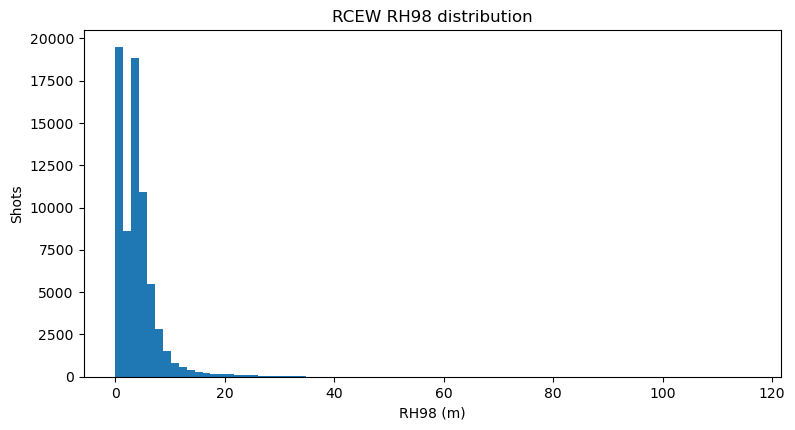

In [17]:
RH_INDICES = [0, 5, 10, 25, 50, 75, 90, 95, 98, 100]

def extract_rh_table(path):
    parts = []

    with h5py.File(path, "r") as h5:
        for beam in list_beams(h5):
            g = h5[beam]

            if "shot_number" not in g or "rh" not in g:
                continue

            shot = np.asarray(g["shot_number"])
            rh = np.asarray(g["rh"])

            if rh.ndim != 2 or rh.shape[0] != len(shot):
                continue

            out = {
                "granule_key": np.repeat(orbit_key(path), len(shot)),
                "beam": np.repeat(beam, len(shot)),
                "shot_number": shot.astype(np.uint64),
            }

            for idx in RH_INDICES:
                if idx < rh.shape[1]:
                    out[f"rh{idx}"] = rh[:, idx]

            parts.append(pd.DataFrame(out))

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

rh_parts = []
for i, p in enumerate(l2a_files, 1):
    df = extract_rh_table(p)
    if not df.empty:
        rh_parts.append(df)
    if i % 25 == 0 or i == len(l2a_files):
        print(f"RH: {i:,}/{len(l2a_files):,} files scanned")

rh_table = pd.concat(rh_parts, ignore_index=True) if rh_parts else pd.DataFrame()

if not rh_table.empty:
    paired_shots = paired_shots.merge(
        rh_table,
        on=["granule_key", "beam", "shot_number"],
        how="left",
        validate="one_to_one",
    )

    rh_cols = [c for c in paired_shots.columns if re.fullmatch(r"rh\d+", c)]
    display(paired_shots[rh_cols].describe().T)

    if "rh98" in paired_shots.columns:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        vals = pd.to_numeric(paired_shots["rh98"], errors="coerce").dropna()
        ax.hist(vals, bins=80)
        ax.set_xlabel("RH98 (m)")
        ax.set_ylabel("Shots")
        ax.set_title("RCEW RH98 distribution")
        plt.show()
else:
    print("No RH arrays found.")


## 14. Full-waveform extraction

L1B stores receive/transmit waveforms as concatenated vectors.  
Each shot is recovered from its 1-based start index and sample count.

The repacker rebuilt those vectors and indices for the retained AOI shots, so this cell also functions as an independent spot-check of the repacked archive.


In [18]:
def get_waveform_segment(group, prefix, shot_index):
    wf_name = f"{prefix}waveform"
    start_name = f"{prefix}_sample_start_index"
    count_name = f"{prefix}_sample_count"

    if not all(name in group for name in [wf_name, start_name, count_name]):
        return None

    start = int(group[start_name][shot_index])
    count = int(group[count_name][shot_index])

    # GEDI waveform start indices are 1-based.
    i0 = start - 1
    i1 = i0 + count

    if i0 < 0 or i1 > len(group[wf_name]):
        raise IndexError(
            f"Waveform bounds invalid in {group.name}: "
            f"{prefix} start={start}, count={count}, waveform_len={len(group[wf_name])}"
        )

    return np.asarray(group[wf_name][i0:i1])

def load_l1b_waveforms(l1b_path, beam, shot_number):
    with h5py.File(l1b_path, "r") as h5:
        if beam not in h5:
            raise KeyError(f"{beam} not found in {l1b_path.name}")

        g = h5[beam]
        shots = np.asarray(g["shot_number"])
        idx = np.flatnonzero(shots == np.uint64(shot_number))

        if len(idx) != 1:
            raise KeyError(
                f"Expected exactly one match for shot {shot_number} in "
                f"{l1b_path.name} {beam}; found {len(idx)}"
            )

        i = int(idx[0])
        rx = get_waveform_segment(g, "rx", i)
        tx = get_waveform_segment(g, "tx", i)

    return rx, tx

def l1b_path_for_key(key):
    p = l1b_lookup.get(key)
    if p is None:
        raise KeyError(f"No L1B subset for {key}")
    return p


## 15. Plot a single shot in detail

Use this cell interactively by changing `ROW_INDEX`, or leave it at zero for the first paired shot.

The x-axis is waveform sample number rather than physical elevation.  
We can add sample-to-elevation conversion later if we want waveform returns registered vertically against `elev_lowestmode` and `elev_highestreturn`.


granule_key                O02489_02_T00140_02
beam                                  BEAM0000
shot_number                  24890000200049463
quality_flag                                 0
degrade_flag                                70
sensitivity                          -0.568165
surface_flag                                 1
selected_algorithm                           1
num_detectedmodes                            0
elev_lowestmode                    1744.461792
digital_elevation_model            1743.448486
rh98                                       0.0
rh100                                      0.0
Name: 0, dtype: object


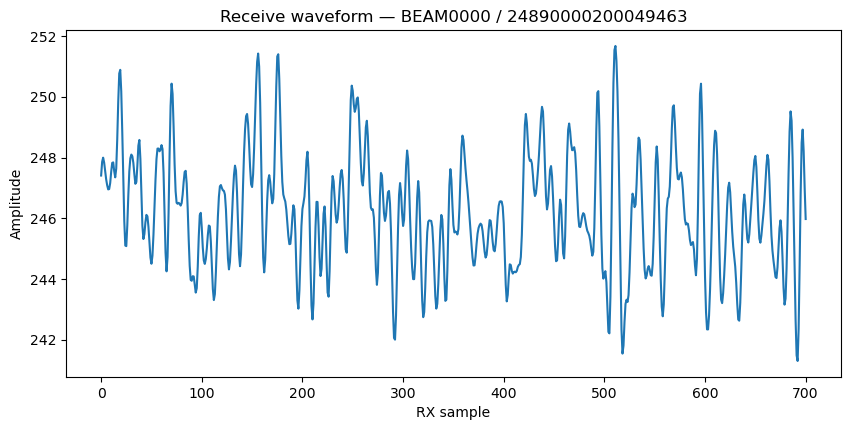

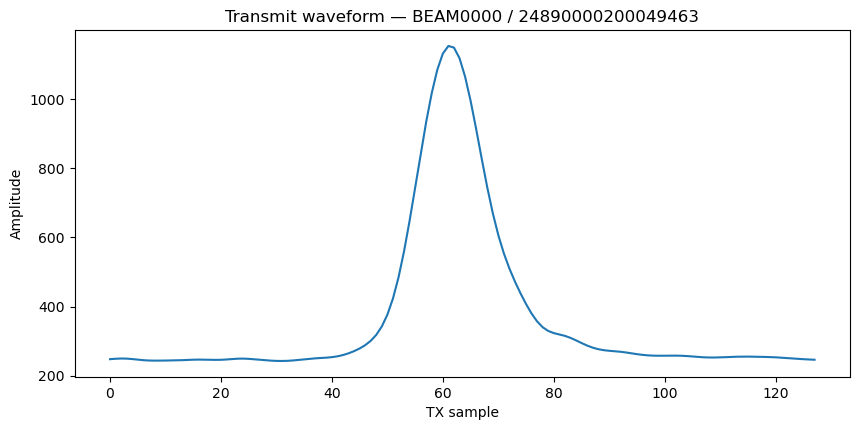

In [19]:
ROW_INDEX = 0

row = paired_shots.iloc[ROW_INDEX]

rx, tx = load_l1b_waveforms(
    l1b_path_for_key(row["granule_key"]),
    row["beam"],
    row["shot_number"],
)

print(row[
    [c for c in [
        "granule_key", "beam", "shot_number",
        "quality_flag", "degrade_flag", "sensitivity",
        "surface_flag", "selected_algorithm", "num_detectedmodes",
        "elev_lowestmode", "digital_elevation_model",
        "rh98", "rh100"
    ] if c in row.index]
])

if rx is not None:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(np.arange(len(rx)), rx)
    ax.set_xlabel("RX sample")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Receive waveform — {row['beam']} / {int(row['shot_number'])}")
    plt.show()

if tx is not None:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(np.arange(len(tx)), tx)
    ax.set_xlabel("TX sample")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Transmit waveform — {row['beam']} / {int(row['shot_number'])}")
    plt.show()


## 16. Select representative waveform classes

The purpose is to compare morphology, not to define a final filter.

Classes are generated only when the necessary fields exist:

- `standard_good`: `quality_flag == 1`, no obvious degradation, high sensitivity
- `quality_bad`: `quality_flag == 0`
- `degraded`: non-zero / uncommon degradation code
- `low_sensitivity`: lower tail of the AOI sensitivity distribution
- `many_modes`: upper tail of detected-mode count
- `large_dem_residual`: large absolute lowest-mode minus DEM residual

The categories may overlap. That is scientifically useful because it reveals whether different diagnostics identify the same shots.


In [20]:
rng = np.random.default_rng(RANDOM_SEED)

def sample_rows(df, mask, n=N_WAVEFORMS_PER_CLASS):
    idx = np.flatnonzero(np.asarray(mask.fillna(False) if hasattr(mask, "fillna") else mask))
    if len(idx) == 0:
        return df.iloc[0:0].copy()
    choose = rng.choice(idx, size=min(n, len(idx)), replace=False)
    return df.iloc[choose].copy()

classes = {}

if {"quality_flag", "sensitivity"}.issubset(paired_shots.columns):
    deg_ok = (
        paired_shots["degrade_flag"].eq(0)
        if "degrade_flag" in paired_shots.columns
        else pd.Series(True, index=paired_shots.index)
    )

    classes["standard_good"] = sample_rows(
        paired_shots,
        paired_shots["quality_flag"].eq(1)
        & deg_ok
        & pd.to_numeric(paired_shots["sensitivity"], errors="coerce").ge(0.9)
    )

    classes["quality_bad"] = sample_rows(
        paired_shots,
        paired_shots["quality_flag"].eq(0)
    )

if "degrade_flag" in paired_shots.columns:
    classes["degraded"] = sample_rows(
        paired_shots,
        paired_shots["degrade_flag"].ne(0)
    )

if "sensitivity" in paired_shots.columns:
    s = pd.to_numeric(paired_shots["sensitivity"], errors="coerce")
    q10 = s.quantile(0.10)
    classes["low_sensitivity"] = sample_rows(
        paired_shots,
        s.le(q10)
    )

if "num_detectedmodes" in paired_shots.columns:
    modes = pd.to_numeric(paired_shots["num_detectedmodes"], errors="coerce")
    q90 = modes.quantile(0.90)
    classes["many_modes"] = sample_rows(
        paired_shots,
        modes.ge(q90)
    )

if "lowestmode_minus_dem_m" in paired_shots.columns:
    abs_r = paired_shots["lowestmode_minus_dem_m"].abs()
    q99 = abs_r.quantile(0.99)
    classes["large_dem_residual"] = sample_rows(
        paired_shots,
        abs_r.ge(q99)
    )

class_summary = pd.concat(
    [
        df.assign(diagnostic_class=name)
        for name, df in classes.items()
        if not df.empty
    ],
    ignore_index=True,
) if any(not df.empty for df in classes.values()) else pd.DataFrame()

display(
    class_summary[
        [c for c in [
            "diagnostic_class", "granule_key", "beam", "shot_number",
            "quality_flag", "degrade_flag", "sensitivity",
            "surface_flag", "selected_algorithm", "num_detectedmodes",
            "elev_lowestmode", "digital_elevation_model",
            "lowestmode_minus_dem_m", "rh98"
        ] if c in class_summary.columns]
    ]
)


,diagnostic_class,granule_key,beam,shot_number,quality_flag,degrade_flag,sensitivity,surface_flag,selected_algorithm,num_detectedmodes,elev_lowestmode,digital_elevation_model,lowestmode_minus_dem_m,rh98
0,standard_good,O13796_03_T06677_02,BEAM0110,137960600300539747,1,0,0.951290,1,1,1,1348.952271,1346.359253,2.593018,3.67
1,standard_good,O03317_03_T03831_02,BEAM0010,33170200300245761,1,0,0.943333,1,1,1,1220.589478,1220.750854,-0.161377,2.80
2,standard_good,O20778_02_T02986_02,BEAM1000,207780800200105248,1,0,0.948543,1,1,1,2153.406250,2153.186523,0.219727,2.42
3,standard_good,O22292_03_T08100_02,BEAM0101,222920500300241034,1,0,0.962537,1,1,1,1436.009521,1429.858276,6.151245,3.37
4,quality_bad,O21285_03_T00985_02,BEAM1000,212850800300134237,0,0,0.909120,0,1,0,5768.869629,1283.547363,4485.322266,0.00
5,quality_bad,O08733_03_T03678_02,BEAM0000,87330000300244732,0,0,3.224204,1,1,0,1623.249512,1732.876465,-109.626953,0.00
6,quality_bad,O04611_02_T04409_02,BEAM0011,46110300200085749,0,70,2.200951,1,1,0,1783.505737,1687.376953,96.128784,0.00
7,quality_bad,O18203_03_T08100_02,BEAM0011,182030300300129353,0,0,-0.161989,0,1,0,-55.827316,1348.645508,-1404.472778,0.00
8,degraded,O20366_02_T09795_02,BEAM1011,203661100200066930,1,70,0.974568,1,1,2,1703.162354,1742.184814,-39.022461,24.84
9,degraded,O13674_03_T00985_02,BEAM1000,136740800300244423,1,30,0.964932,1,1,1,1279.079834,1275.852539,3.227295,11.79


## 17. Plot representative receive waveforms by diagnostic class


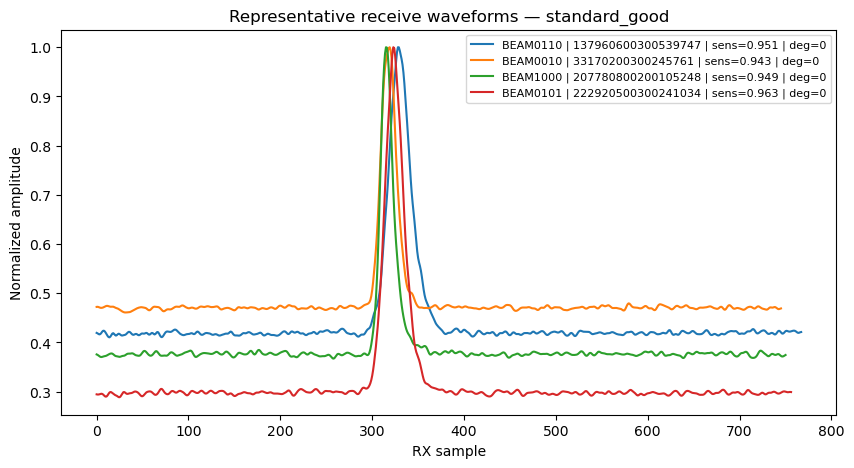

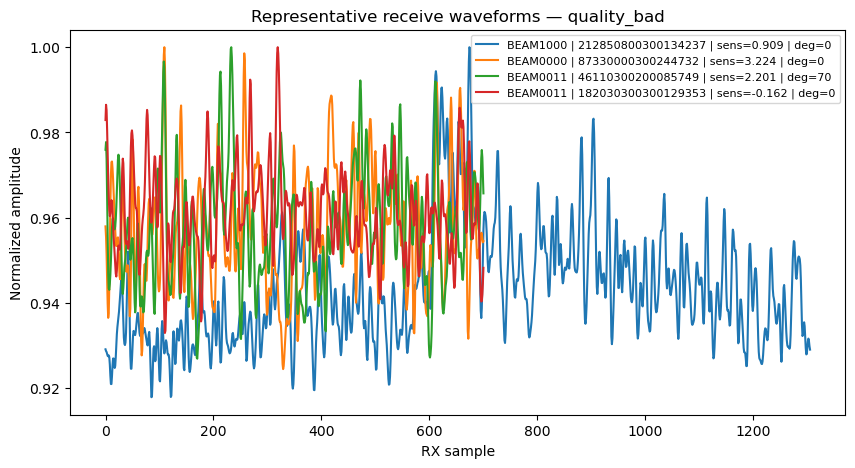

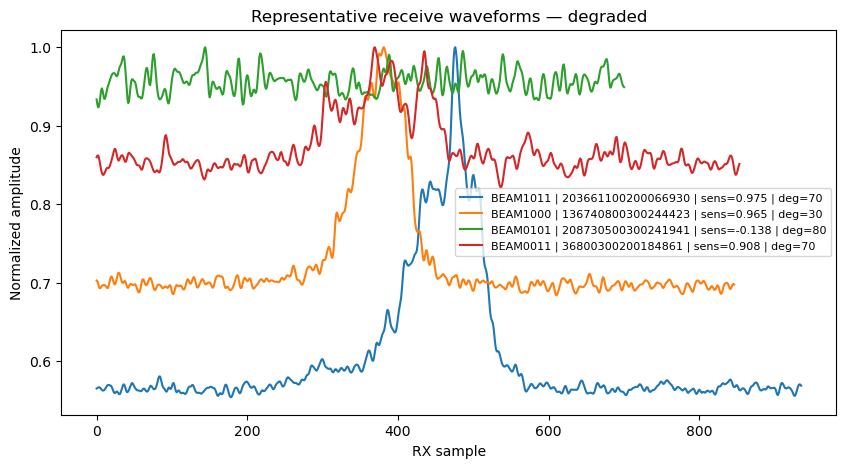

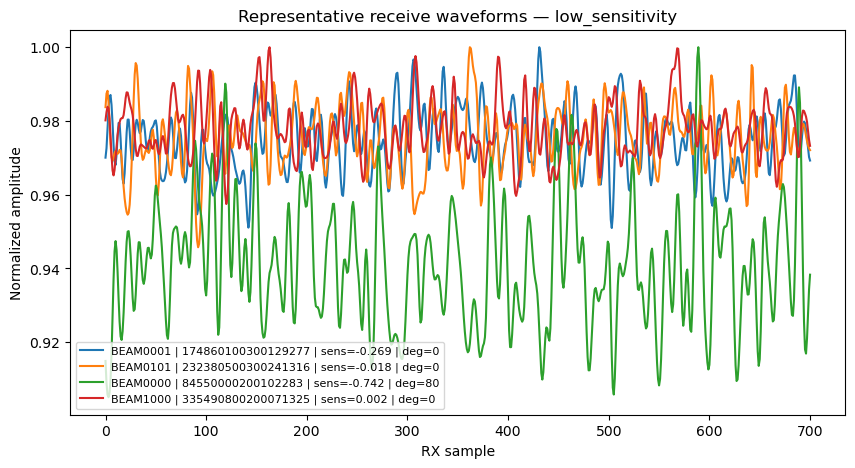

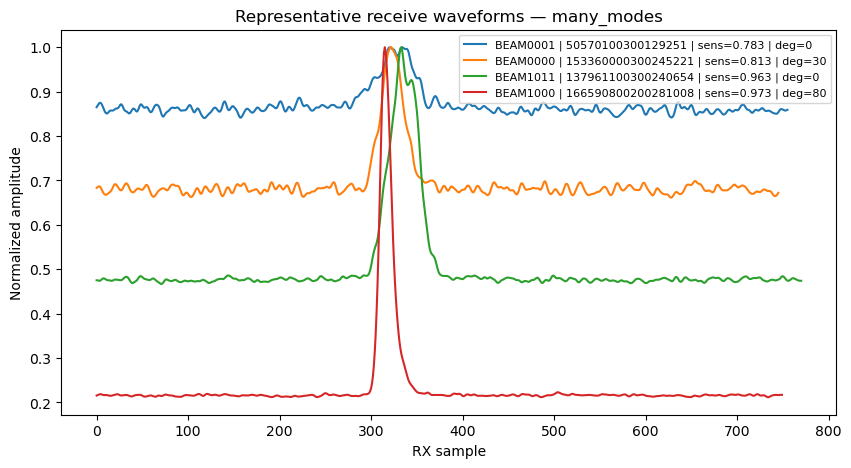

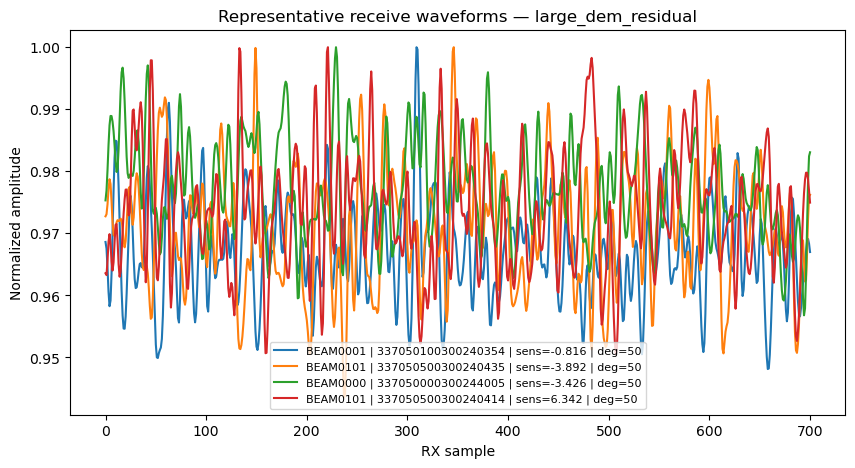

In [21]:
def plot_waveform_class(df, class_name):
    if df.empty:
        print(f"{class_name}: no qualifying shots")
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    plotted = 0
    for _, row in df.iterrows():
        try:
            rx, _ = load_l1b_waveforms(
                l1b_path_for_key(row["granule_key"]),
                row["beam"],
                row["shot_number"],
            )
        except Exception as exc:
            print("Waveform read failed:", exc)
            continue

        if rx is None or len(rx) == 0:
            continue

        # Normalize only for shape comparison in this multi-shot overlay.
        # Raw-amplitude plots remain available in the single-shot cell.
        rx = np.asarray(rx, dtype=float)
        denom = np.nanmax(np.abs(rx))
        rxn = rx / denom if np.isfinite(denom) and denom > 0 else rx

        label_bits = [
            str(row["beam"]),
            str(int(row["shot_number"])),
        ]
        if "sensitivity" in row.index and pd.notna(row["sensitivity"]):
            label_bits.append(f"sens={row['sensitivity']:.3f}")
        if "degrade_flag" in row.index and pd.notna(row["degrade_flag"]):
            label_bits.append(f"deg={row['degrade_flag']}")

        ax.plot(np.arange(len(rxn)), rxn, label=" | ".join(label_bits))
        plotted += 1

    ax.set_xlabel("RX sample")
    ax.set_ylabel("Normalized amplitude")
    ax.set_title(f"Representative receive waveforms — {class_name}")
    if plotted:
        ax.legend(fontsize=8)
    plt.show()

for name, df in classes.items():
    plot_waveform_class(df, name)


## 18. Flag combinations and retention scenarios

This cell quantifies several candidate filtering rules **without modifying the data**.

The standard V2-style criterion `quality_flag == 1` plus high sensitivity is shown alongside stricter and looser alternatives.  
These are scenarios for comparison, not recommendations.

Note that some later GEDI products accept several low-order `degrade_flag` codes as not significantly degraded rather than requiring exactly zero; the AOI-specific distributions above should inform whether such distinctions matter here.


In [22]:
scenario = pd.DataFrame(index=paired_shots.index)

if "quality_flag" in paired_shots:
    scenario["quality_1"] = paired_shots["quality_flag"].eq(1)

if "degrade_flag" in paired_shots:
    scenario["degrade_0"] = paired_shots["degrade_flag"].eq(0)
    scenario["degrade_l4d_allowed"] = paired_shots["degrade_flag"].isin(
        [0, 3, 10, 13, 20, 23, 30, 33]
    )

if "sensitivity" in paired_shots:
    sens = pd.to_numeric(paired_shots["sensitivity"], errors="coerce")
    scenario["sensitivity_ge_0_90"] = sens.ge(0.90)
    scenario["sensitivity_ge_0_95"] = sens.ge(0.95)

candidate_masks = {}

if {"quality_1", "degrade_0", "sensitivity_ge_0_90"}.issubset(scenario.columns):
    candidate_masks["strict_q1_deg0_sens90"] = (
        scenario["quality_1"]
        & scenario["degrade_0"]
        & scenario["sensitivity_ge_0_90"]
    )

if {"quality_1", "degrade_l4d_allowed", "sensitivity_ge_0_90"}.issubset(scenario.columns):
    candidate_masks["q1_alloweddeg_sens90"] = (
        scenario["quality_1"]
        & scenario["degrade_l4d_allowed"]
        & scenario["sensitivity_ge_0_90"]
    )

if {"quality_1", "sensitivity_ge_0_90"}.issubset(scenario.columns):
    candidate_masks["q1_sens90"] = (
        scenario["quality_1"]
        & scenario["sensitivity_ge_0_90"]
    )

if "quality_1" in scenario.columns:
    candidate_masks["quality_only"] = scenario["quality_1"]

rows = []
for name, mask in candidate_masks.items():
    rows.append({
        "scenario": name,
        "retained": int(mask.sum()),
        "total": len(mask),
        "retained_percent": 100 * mask.mean(),
    })

scenario_summary = pd.DataFrame(rows).sort_values("retained_percent", ascending=False)
display(scenario_summary)


,scenario,retained,total,retained_percent
3,quality_only,34007,71100,47.829817
2,q1_sens90,34007,71100,47.829817
1,q1_alloweddeg_sens90,27984,71100,39.358650
0,strict_q1_deg0_sens90,26151,71100,36.780591


## 19. Diagnose whether filtering changes the AOI sample

A quality filter can create a biased ecological sample even when it improves measurement reliability.

For each candidate scenario we therefore compare, where available:

- beam composition,
- solar elevation,
- DEM elevation,
- sensitivity,
- RH98,
- spatial footprint coverage.

A filter that disproportionately removes particular beams, terrain, or parts of the AOI deserves scrutiny before use in ecological inference.


In [23]:
diagnostic_vars = [
    c for c in [
        "solar_elevation",
        "digital_elevation_model",
        "sensitivity",
        "rh98",
        "lowestmode_minus_dem_m",
        "l1b_l2a_horizontal_offset_m",
    ]
    if c in paired_shots.columns
]

summary_rows = []

for name, mask in {"all_spatial": pd.Series(True, index=paired_shots.index), **candidate_masks}.items():
    sub = paired_shots.loc[mask]

    row = {
        "scenario": name,
        "n": len(sub),
        "percent_of_spatial": 100 * len(sub) / len(paired_shots) if len(paired_shots) else np.nan,
        "n_beams": sub["beam"].nunique(),
        "n_granules": sub["granule_key"].nunique(),
    }

    for col in diagnostic_vars:
        vals = pd.to_numeric(sub[col], errors="coerce")
        row[f"{col}_median"] = vals.median()
        row[f"{col}_p05"] = vals.quantile(0.05)
        row[f"{col}_p95"] = vals.quantile(0.95)

    summary_rows.append(row)

filter_diagnostic_summary = pd.DataFrame(summary_rows)
display(filter_diagnostic_summary)


,scenario,n,percent_of_spatial,n_beams,n_granules,solar_elevation_median,solar_elevation_p05,solar_elevation_p95,digital_elevation_model_median,digital_elevation_model_p05,digital_elevation_model_p95,sensitivity_median,sensitivity_p05,sensitivity_p95,rh98_median,rh98_p05,rh98_p95,lowestmode_minus_dem_m_median,lowestmode_minus_dem_m_p05,lowestmode_minus_dem_m_p95,l1b_l2a_horizontal_offset_m_median,l1b_l2a_horizontal_offset_m_p05,l1b_l2a_horizontal_offset_m_p95
0,all_spatial,71100,100.000000,8,67,1.541783,-59.225276,59.118544,1485.022095,1163.596069,1994.423950,0.923080,-0.963463,2.842374,3.40,0.00,10.0505,1.263733,-24.937421,4472.860083,1.279102,0.000000,4.782966
1,strict_q1_deg0_sens90,26151,36.780591,8,43,-2.440090,-65.911526,42.509317,1471.282593,1160.498657,1962.417664,0.950827,0.905704,0.975752,4.26,2.58,10.8200,-0.201416,-11.304932,9.979004,1.503743,0.376265,4.517138
2,q1_alloweddeg_sens90,27984,39.358650,8,46,-2.445693,-65.908390,44.402201,1469.733887,1160.727319,1967.971753,0.951112,0.905668,0.975570,4.26,2.58,10.9300,-0.176270,-11.262024,10.015411,1.499366,0.367605,4.454717
3,q1_sens90,34007,47.829817,8,55,-1.254439,-65.893930,58.278461,1476.886597,1161.067529,1987.801929,0.951490,0.905901,0.974846,4.27,2.58,11.6270,-0.107178,-11.578503,10.298572,1.750117,0.393890,4.822944
4,quality_only,34007,47.829817,8,55,-1.254439,-65.893930,58.278461,1476.886597,1161.067529,1987.801929,0.951490,0.905901,0.974846,4.27,2.58,11.6270,-0.107178,-11.578503,10.298572,1.750117,0.393890,4.822944


## 20. Inspect extreme / contradictory cases

These are especially informative:

- `quality_flag == 1` but large DEM residual,
- `quality_flag == 0` but apparently clean waveform / high sensitivity,
- `surface_flag == 1` but large within-AOI residual relative to most shots,
- low sensitivity with simple single-mode waveforms,
- many detected modes in otherwise low-stature areas.

They test whether a generic filtering recipe maps cleanly onto the ecological/measurement problem in the RCEW.


In [24]:
columns_to_show = [
    c for c in [
        "granule_key", "beam", "shot_number",
        "quality_flag", "degrade_flag", "sensitivity", "surface_flag",
        "selected_algorithm", "selected_mode_flag", "num_detectedmodes",
        "elev_lowestmode", "digital_elevation_model",
        "lowestmode_minus_dem_m",
        "l1b_l2a_horizontal_offset_m",
        "rh50", "rh90", "rh98", "rh100",
    ]
    if c in paired_shots.columns
]

if {"quality_flag", "lowestmode_minus_dem_m"}.issubset(paired_shots.columns):
    threshold = paired_shots["lowestmode_minus_dem_m"].abs().quantile(0.99)
    print("quality_flag == 1 with top-1% absolute DEM residual:")
    display(
        paired_shots.loc[
            paired_shots["quality_flag"].eq(1)
            & paired_shots["lowestmode_minus_dem_m"].abs().ge(threshold),
            columns_to_show,
        ].head(30)
    )

if {"quality_flag", "sensitivity"}.issubset(paired_shots.columns):
    print("\nquality_flag == 0 but sensitivity >= 0.95:")
    display(
        paired_shots.loc[
            paired_shots["quality_flag"].eq(0)
            & pd.to_numeric(paired_shots["sensitivity"], errors="coerce").ge(0.95),
            columns_to_show,
        ].head(30)
    )


quality_flag == 1 with top-1% absolute DEM residual:


,granule_key,beam,shot_number,quality_flag,degrade_flag,sensitivity,surface_flag,selected_algorithm,selected_mode_flag,num_detectedmodes,elev_lowestmode,digital_elevation_model,lowestmode_minus_dem_m,l1b_l2a_horizontal_offset_m,rh50,rh90,rh98,rh100



quality_flag == 0 but sensitivity >= 0.95:


,granule_key,beam,shot_number,quality_flag,degrade_flag,sensitivity,surface_flag,selected_algorithm,selected_mode_flag,num_detectedmodes,elev_lowestmode,digital_elevation_model,lowestmode_minus_dem_m,l1b_l2a_horizontal_offset_m,rh50,rh90,rh98,rh100
2,O02489_02_T00140_02,BEAM0000,24890000200049465,0,70,2.187813,1,1,0,0,1744.534912,1722.826416,21.708496,0.0,0.0,0.0,0.0,0.0
5,O02489_02_T00140_02,BEAM0000,24890000200049468,0,70,2.124224,1,1,0,0,1744.541992,1694.354736,50.187256,0.0,0.0,0.0,0.0,0.0
7,O02489_02_T00140_02,BEAM0000,24890000200049470,0,70,2.429671,1,1,0,0,1759.840088,1705.639526,54.200562,0.0,0.0,0.0,0.0,0.0
9,O02489_02_T00140_02,BEAM0000,24890000200049472,0,70,3.099019,1,1,0,0,1663.085327,1739.532959,-76.447632,0.0,0.0,0.0,0.0,0.0
19,O02489_02_T00140_02,BEAM0000,24890000200049482,0,70,1.519185,1,1,0,0,1736.930542,1617.839844,119.090698,0.0,0.0,0.0,0.0,0.0
20,O02489_02_T00140_02,BEAM0000,24890000200049483,0,70,1.774943,1,1,0,0,1737.028442,1597.766602,139.261841,0.0,0.0,0.0,0.0,0.0
21,O02489_02_T00140_02,BEAM0000,24890000200049484,0,70,2.258819,1,1,0,0,1736.615845,1597.539551,139.076294,0.0,0.0,0.0,0.0,0.0
26,O02489_02_T00140_02,BEAM0000,24890000200049489,0,70,2.056408,1,1,0,0,1736.973389,1636.445923,100.527466,0.0,0.0,0.0,0.0,0.0
27,O02489_02_T00140_02,BEAM0000,24890000200049490,0,70,3.066572,1,1,0,0,1737.187378,1653.867432,83.319946,0.0,0.0,0.0,0.0,0.0
29,O02489_02_T00140_02,BEAM0000,24890000200049492,0,70,3.945214,1,1,0,0,1737.571411,1674.837646,62.733765,0.0,0.0,0.0,0.0,0.0


## 21. Save compact diagnostic tables (optional)

This does **not** rewrite or filter the HDF5 archive.

Uncomment the exports if we want persistent AOI-level diagnostic tables after inspecting the notebook results.


In [ ]:
DIAGNOSTIC_OUT = SUBSET_ROOT / "diagnostics"

# DIAGNOSTIC_OUT.mkdir(parents=True, exist_ok=True)
#
# paired_shots.to_parquet(
#     DIAGNOSTIC_OUT / "RCEW_GEDI_L1B_L2A_paired_shot_diagnostics.parquet",
#     index=False,
# )
#
# scenario_summary.to_csv(
#     DIAGNOSTIC_OUT / "RCEW_GEDI_quality_filter_scenarios.csv",
#     index=False,
# )
#
# filter_diagnostic_summary.to_csv(
#     DIAGNOSTIC_OUT / "RCEW_GEDI_filter_distribution_diagnostics.csv",
#     index=False,
# )
#
# print("Would write diagnostics to:", DIAGNOSTIC_OUT)


## 22. Interpretation checklist

After running the notebook, the next filter decision should answer:

1. **How many spatially valid RCEW shots fail `quality_flag` and why?**
2. **Which `degrade_flag` codes actually occur, and are they associated with measurable coordinate/elevation problems?**
3. **Does sensitivity have a clear breakpoint in waveform quality or derived heights?**
4. **Do candidate filters remove shots non-randomly in space, beam, terrain, or solar geometry?**
5. **Are the extreme RH values supported by plausible full waveforms?**
6. **Do large DEM residuals correspond to obvious waveform/ground-selection failures, or simply terrain/support differences?**
7. **Does one filtering rule improve measurement reliability enough to justify the ecological sample it removes?**

The final science filter should be chosen from these observed tradeoffs rather than imported wholesale from a forest-oriented GEDI workflow.


## Proposed retained GEDI science subset

Apply the **same primary science-quality rule used for the NCA**:

- `quality_flag == 1`
- `degrade_flag ∈ {0, 3, 10, 13, 20, 23, 30, 33}`
- finite sensitivity in the physical range `[0, 1]`
- `sensitivity >= 0.90`

Do not assume that RCEW has the same empirical degradation-code frequencies as the NCA. The cell below reports which accepted and rejected codes actually occur here.

This cell does not modify the HDF5 archive. It creates an in-memory `gedi_keep` table and evaluates the retained RCEW population.


In [25]:
# =============================================================================
# Proposed primary GEDI science-quality subset
# =============================================================================

ACCEPTED_DEGRADE_FLAGS = {0, 3, 10, 13, 20, 23, 30, 33}
MIN_SENSITIVITY = 0.90

required = {"quality_flag", "degrade_flag", "sensitivity"}
missing = required - set(paired_shots.columns)

if missing:
    raise KeyError(
        f"Required filtering fields missing: {sorted(missing)}"
    )

sens = pd.to_numeric(
    paired_shots["sensitivity"],
    errors="coerce",
)

valid_sensitivity = (
    sens.notna()
    & np.isfinite(sens)
    & sens.between(0.0, 1.0, inclusive="both")
)

keep_mask = (
    paired_shots["quality_flag"].eq(1)
    & paired_shots["degrade_flag"].isin(ACCEPTED_DEGRADE_FLAGS)
    & valid_sensitivity
    & sens.ge(MIN_SENSITIVITY)
)

gedi_keep = paired_shots.loc[keep_mask].copy()

print("PROPOSED GEDI SCIENCE SUBSET")
print("----------------------------")
print(f"Spatial subset shots: {len(paired_shots):,}")
print(f"Retained shots:       {len(gedi_keep):,}")
print(
    f"Retention:            "
    f"{100 * len(gedi_keep) / len(paired_shots):.2f}%"
)

print(
    "\nAccepted degrade flags actually present:",
    sorted(
        set(
            gedi_keep["degrade_flag"]
            .dropna()
            .astype(int)
        )
    )
)

# -------------------------------------------------------------------------
# Sequential attrition
# -------------------------------------------------------------------------

stage_masks = {
    "all spatial shots":
        pd.Series(True, index=paired_shots.index),

    "valid sensitivity [0,1]":
        valid_sensitivity,

    "quality_flag == 1":
        valid_sensitivity
        & paired_shots["quality_flag"].eq(1),

    "quality + accepted degrade":
        valid_sensitivity
        & paired_shots["quality_flag"].eq(1)
        & paired_shots["degrade_flag"].isin(
            ACCEPTED_DEGRADE_FLAGS
        ),

    "final: + sensitivity >= 0.90":
        keep_mask,
}

attrition_rows = []

for stage, mask in stage_masks.items():

    n = int(mask.sum())

    attrition_rows.append(
        {
            "stage": stage,
            "n": n,
            "percent_of_spatial":
                100 * n / len(paired_shots),
        }
    )

attrition = pd.DataFrame(attrition_rows)

display(attrition)

# -------------------------------------------------------------------------
# Retained flag combinations
# -------------------------------------------------------------------------

print("\nRetained quality/degrade combinations:")

display(
    gedi_keep
    .groupby(
        ["quality_flag", "degrade_flag"]
    )
    .size()
    .rename("n")
    .reset_index()
    .assign(
        percent=lambda d:
            100 * d["n"] / d["n"].sum()
    )
)

# -------------------------------------------------------------------------
# Beam-specific retention
# -------------------------------------------------------------------------

beam_before = (
    paired_shots
    .groupby("beam")
    .size()
    .rename("n_spatial")
    .to_frame()
)

beam_after = (
    gedi_keep
    .groupby("beam")
    .size()
    .rename("n_keep")
    .to_frame()
)

beam_compare = (
    beam_before
    .join(
        beam_after,
        how="left",
    )
    .fillna(0)
)

beam_compare["retained_percent"] = (
    100
    * beam_compare["n_keep"]
    / beam_compare["n_spatial"]
)

display(beam_compare)


PROPOSED GEDI SCIENCE SUBSET
----------------------------
Spatial subset shots: 71,100
Retained shots:       27,984
Retention:            39.36%

Accepted degrade flags actually present: [0, 30]


,stage,n,percent_of_spatial
0,all spatial shots,71100,100.000000
1,"valid sensitivity [0,1]",58188,81.839662
2,quality_flag == 1,34007,47.829817
3,quality + accepted degrade,27984,39.358650
4,final: + sensitivity >= 0.90,27984,39.358650



Retained quality/degrade combinations:


,quality_flag,degrade_flag,n,percent
0,1,0,26151,93.449828
1,1,30,1833,6.550172


,n_spatial,n_keep,retained_percent
beam,,,
BEAM0000,8725,1505,17.249284
BEAM0001,8671,1793,20.678122
BEAM0010,8652,2458,28.409616
BEAM0011,8672,2963,34.167435
BEAM0101,8840,4653,52.635747
BEAM0110,8843,4566,51.634061
BEAM1000,9334,4914,52.646240
BEAM1011,9363,5132,54.811492


,subset,variable,n,p01,p05,median,mean,p95,p99
0,all_spatial,sensitivity,71100,-9.137339,-0.963463,0.923080,1.227074,2.842374,11.268149
1,all_spatial,rh50,71100,-0.860000,-0.410000,0.000000,0.236726,1.340000,7.470000
2,all_spatial,rh90,71100,0.000000,0.000000,2.130000,2.623201,7.060000,17.680000
3,all_spatial,rh95,71100,0.000000,0.000000,2.760000,3.251343,8.600000,19.800099
4,all_spatial,rh98,71100,0.000000,0.000000,3.400000,3.864931,10.050500,21.350100
5,all_spatial,rh100,71100,0.000000,0.000000,4.380000,4.701984,11.750000,23.210099
6,all_spatial,lowestmode_minus_dem_m,71100,-64007.377891,-24.937421,1.263733,-274.576935,4472.860083,5875.802627
7,all_spatial,l1b_l2a_horizontal_offset_m,71100,0.000000,0.000000,1.279102,1.678019,4.782966,6.029022
8,all_spatial,digital_elevation_model,71100,1127.467285,1163.596069,1485.022095,1513.223511,1994.423950,2105.123291
9,all_spatial,solar_elevation,71100,-67.057320,-59.225276,1.541783,4.756773,59.118544,64.893646


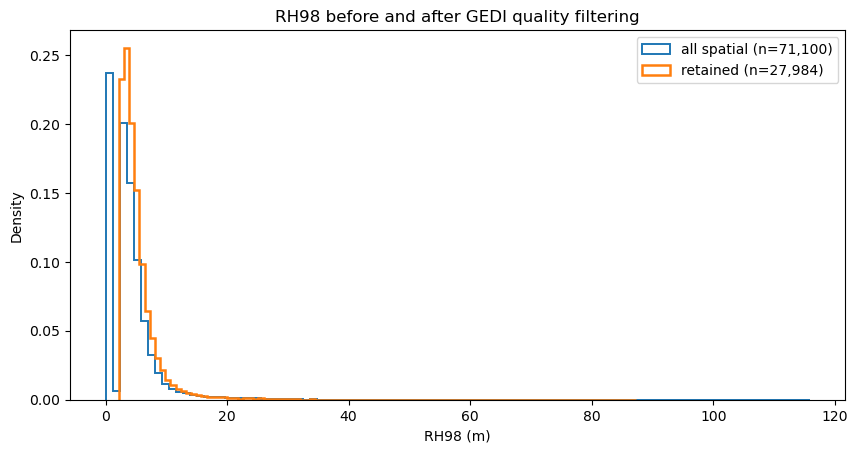

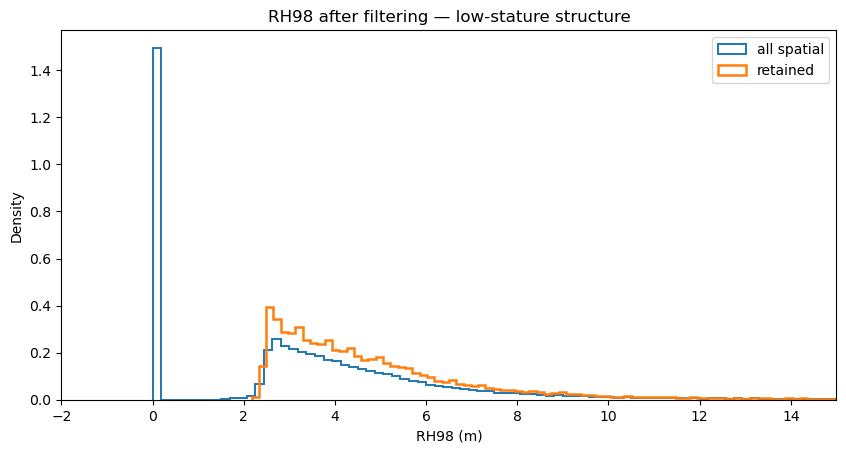

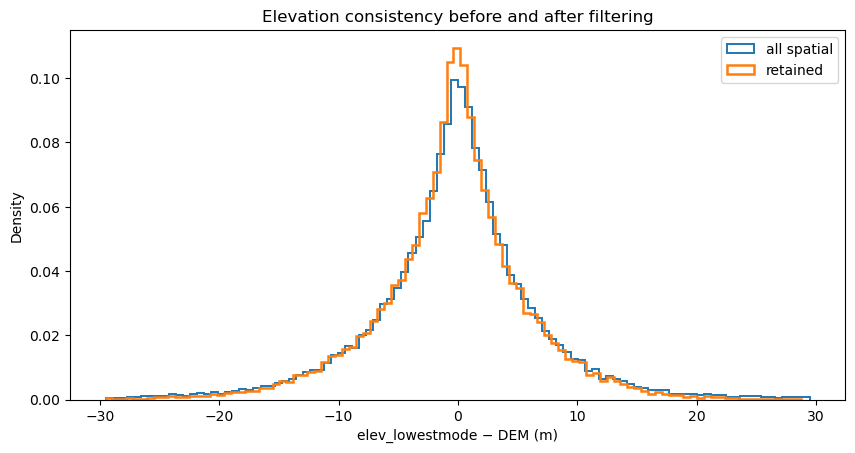

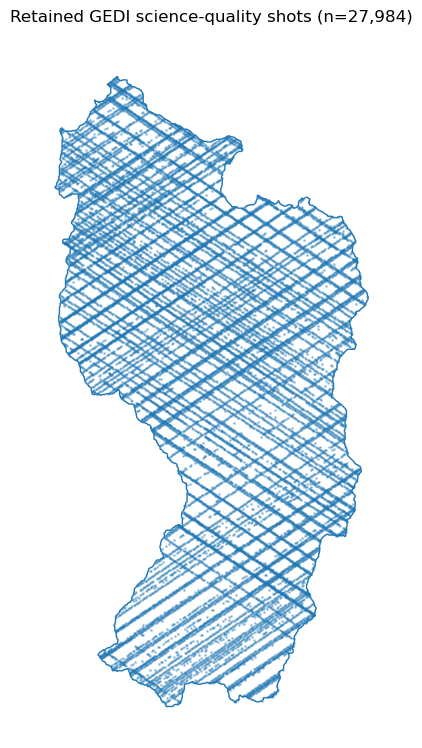

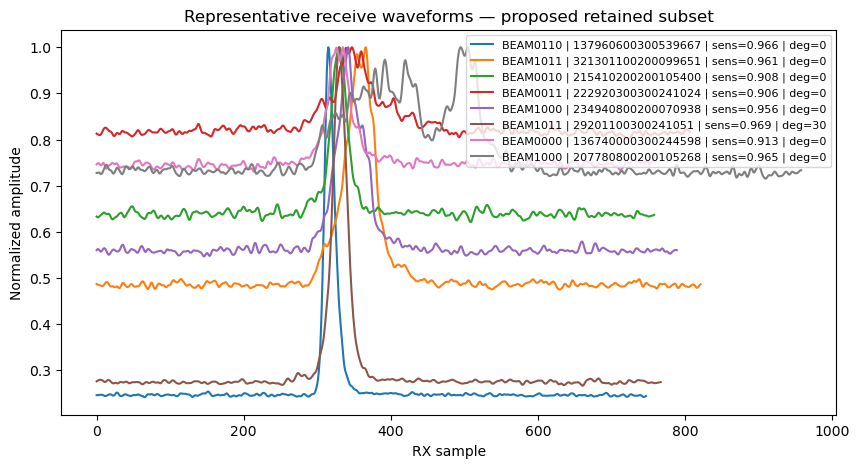


`gedi_keep` contains 27,984 retained shots.


In [26]:
# =============================================================================
# What does the retained GEDI population look like?
# =============================================================================

# -------------------------------------------------------------------------
# Summary statistics before vs after filtering
# -------------------------------------------------------------------------

compare_vars = [
    c for c in [
        "sensitivity",
        "rh50",
        "rh90",
        "rh95",
        "rh98",
        "rh100",
        "lowestmode_minus_dem_m",
        "l1b_l2a_horizontal_offset_m",
        "digital_elevation_model",
        "solar_elevation",
        "num_detectedmodes",
    ]
    if c in paired_shots.columns
]

summary_rows = []

for label, df in [
    ("all_spatial", paired_shots),
    ("retained", gedi_keep),
]:

    for col in compare_vars:

        x = (
            pd.to_numeric(
                df[col],
                errors="coerce",
            )
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )

        if x.empty:
            continue

        summary_rows.append(
            {
                "subset": label,
                "variable": col,
                "n": len(x),
                "p01": x.quantile(0.01),
                "p05": x.quantile(0.05),
                "median": x.median(),
                "mean": x.mean(),
                "p95": x.quantile(0.95),
                "p99": x.quantile(0.99),
            }
        )

filter_summary = pd.DataFrame(
    summary_rows
)

display(filter_summary)

# -------------------------------------------------------------------------
# RH98 before vs after filtering
# -------------------------------------------------------------------------

if "rh98" in paired_shots.columns:

    raw_rh98 = (
        pd.to_numeric(
            paired_shots["rh98"],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    keep_rh98 = (
        pd.to_numeric(
            gedi_keep["rh98"],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    fig, ax = plt.subplots(
        figsize=(10, 4.8)
    )

    ax.hist(
        raw_rh98,
        bins=100,
        histtype="step",
        linewidth=1.4,
        density=True,
        label=f"all spatial (n={len(raw_rh98):,})",
    )

    ax.hist(
        keep_rh98,
        bins=100,
        histtype="step",
        linewidth=1.8,
        density=True,
        label=f"retained (n={len(keep_rh98):,})",
    )

    ax.set_xlabel("RH98 (m)")
    ax.set_ylabel("Density")
    ax.set_title(
        "RH98 before and after GEDI quality filtering"
    )
    ax.legend()

    plt.show()

    # -------------------------------------------------------------
    # Zoom into the ecologically interesting low-stature range
    # -------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 4.8)
    )

    ax.hist(
        raw_rh98[
            (raw_rh98 >= -2)
            & (raw_rh98 <= 15)
        ],
        bins=80,
        histtype="step",
        linewidth=1.4,
        density=True,
        label="all spatial",
    )

    ax.hist(
        keep_rh98[
            (keep_rh98 >= -2)
            & (keep_rh98 <= 15)
        ],
        bins=80,
        histtype="step",
        linewidth=1.8,
        density=True,
        label="retained",
    )

    ax.set_xlim(-2, 15)
    ax.set_xlabel("RH98 (m)")
    ax.set_ylabel("Density")
    ax.set_title(
        "RH98 after filtering — low-stature structure"
    )
    ax.legend()

    plt.show()

# -------------------------------------------------------------------------
# DEM residual before vs after filtering
# -------------------------------------------------------------------------

if "lowestmode_minus_dem_m" in paired_shots.columns:

    raw_resid = (
        pd.to_numeric(
            paired_shots[
                "lowestmode_minus_dem_m"
            ],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    keep_resid = (
        pd.to_numeric(
            gedi_keep[
                "lowestmode_minus_dem_m"
            ],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    # Plot central retained range.
    # Full tails remain in filter_summary.
    lim = max(
        10,
        float(
            np.nanquantile(
                np.abs(keep_resid),
                0.995,
            )
        )
        if len(keep_resid)
        else 10,
    )

    fig, ax = plt.subplots(
        figsize=(10, 4.8)
    )

    ax.hist(
        raw_resid[
            (raw_resid >= -lim)
            & (raw_resid <= lim)
        ],
        bins=100,
        histtype="step",
        linewidth=1.4,
        density=True,
        label="all spatial",
    )

    ax.hist(
        keep_resid[
            (keep_resid >= -lim)
            & (keep_resid <= lim)
        ],
        bins=100,
        histtype="step",
        linewidth=1.8,
        density=True,
        label="retained",
    )

    ax.set_xlabel(
        "elev_lowestmode − DEM (m)"
    )
    ax.set_ylabel("Density")
    ax.set_title(
        "Elevation consistency before and after filtering"
    )
    ax.legend()

    plt.show()

# -------------------------------------------------------------------------
# Spatial coverage after filtering
# -------------------------------------------------------------------------

if {
    "longitude_l2a",
    "latitude_l2a",
}.issubset(
    gedi_keep.columns
):

    retained_xy = (
        gedi_keep
        .dropna(
            subset=[
                "longitude_l2a",
                "latitude_l2a",
            ]
        )
        .copy()
    )

    retained_gdf = gpd.GeoDataFrame(
        retained_xy,
        geometry=gpd.points_from_xy(
            retained_xy["longitude_l2a"],
            retained_xy["latitude_l2a"],
        ),
        crs="EPSG:4326",
    ).to_crs(
        aoi.crs
    )

    fig, ax = plt.subplots(
        figsize=(9, 9)
    )

    aoi.boundary.plot(
        ax=ax,
        linewidth=1,
    )

    retained_gdf.plot(
        ax=ax,
        markersize=1,
        alpha=0.35,
    )

    ax.set_title(
        f"Retained GEDI science-quality shots "
        f"(n={len(retained_gdf):,})"
    )

    ax.set_axis_off()

    plt.show()

# -------------------------------------------------------------------------
# Representative retained waveforms
# -------------------------------------------------------------------------

retained_examples = sample_rows(
    gedi_keep,
    pd.Series(
        True,
        index=gedi_keep.index,
    ),
    n=8,
)

if not retained_examples.empty:

    plot_waveform_class(
        retained_examples,
        "proposed retained subset",
    )

print(
    f"\n`gedi_keep` contains "
    f"{len(gedi_keep):,} retained shots."
)


In [27]:
# =============================================================================
# 10% sample of retained POWER-beam GEDI shots
# =============================================================================

POWER_BEAMS = {
    "BEAM0101",
    "BEAM0110",
    "BEAM1000",
    "BEAM1011",
}

POWER_SAMPLE_FRACTION = 0.10
POWER_SAMPLE_SEED = 42

# All retained science-quality power-beam shots
gedi_power = (
    gedi_keep.loc[
        gedi_keep["beam"].isin(POWER_BEAMS)
    ]
    .copy()
)

# Reproducible 10% random sample
gedi_power_10 = (
    gedi_power
    .sample(
        frac=POWER_SAMPLE_FRACTION,
        random_state=POWER_SAMPLE_SEED,
    )
    .reset_index(drop=True)
)

print("RETAINED POWER-BEAM SAMPLE")
print("--------------------------")
print(f"All retained shots:       {len(gedi_keep):,}")
print(f"Retained power shots:     {len(gedi_power):,}")
print(f"10% power-beam sample:    {len(gedi_power_10):,}")
print()

display(
    pd.DataFrame({
        "all_retained": gedi_keep["beam"].value_counts().sort_index(),
        "power_population": gedi_power["beam"].value_counts().sort_index(),
        "power_10pct": gedi_power_10["beam"].value_counts().sort_index(),
    }).fillna(0).astype(int)
)


RETAINED POWER-BEAM SAMPLE
--------------------------
All retained shots:       27,984
Retained power shots:     19,265
10% power-beam sample:    1,926



,all_retained,power_population,power_10pct
beam,,,
BEAM0000,1505,0,0
BEAM0001,1793,0,0
BEAM0010,2458,0,0
BEAM0011,2963,0,0
BEAM0101,4653,4653,462
BEAM0110,4566,4566,438
BEAM1000,4914,4914,508
BEAM1011,5132,5132,518


In [28]:
# =============================================================================
# Baseline-correct, normalize, and peak-align retained power waveforms
# =============================================================================

ALIGN_LEFT = 120
ALIGN_RIGHT = 180

# Use the outer portions of each waveform to estimate detector background.
BASELINE_EDGE_FRACTION = 0.15


def prepare_rx_for_shape(rx):
    """
    Convert a raw RX waveform into a waveform suitable for comparing shape:

      1. estimate background from waveform edges,
      2. subtract background,
      3. clip negative residuals to zero,
      4. normalize to unit maximum,
      5. return dominant-peak location.

    This is for morphology/Gaussian inspection, not preservation of
    absolute waveform energy.
    """

    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20:
        return None

    n_edge = max(
        5,
        int(len(rx) * BASELINE_EDGE_FRACTION)
    )

    background_samples = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(background_samples)

    corrected = rx - baseline

    # For shape comparison, negative residuals are treated as background.
    corrected = np.clip(corrected, 0, None)

    peak = np.nanmax(corrected)

    if (
        not np.isfinite(peak)
        or peak <= 0
    ):
        return None

    normalized = corrected / peak

    peak_index = int(
        np.nanargmax(normalized)
    )

    return {
        "waveform": normalized,
        "peak_index": peak_index,
        "baseline": baseline,
        "raw_peak_above_baseline": peak,
    }


aligned_waveforms = []
waveform_metadata = []

relative_samples = np.arange(
    -ALIGN_LEFT,
    ALIGN_RIGHT + 1,
)


for i, row in gedi_power_10.iterrows():

    try:

        rx, _ = load_l1b_waveforms(
            l1b_path_for_key(
                row["granule_key"]
            ),
            row["beam"],
            row["shot_number"],
        )

    except Exception:
        continue

    if rx is None:
        continue

    prepared = prepare_rx_for_shape(rx)

    if prepared is None:
        continue

    wf = prepared["waveform"]
    peak_idx = prepared["peak_index"]

    start = peak_idx - ALIGN_LEFT
    stop = peak_idx + ALIGN_RIGHT + 1

    # Require the complete alignment window.
    if (
        start < 0
        or stop > len(wf)
    ):
        continue

    aligned = wf[start:stop]

    aligned_waveforms.append(aligned)

    waveform_metadata.append({
        "granule_key": row["granule_key"],
        "beam": row["beam"],
        "shot_number": row["shot_number"],
        "sensitivity": row["sensitivity"],
        "rh98": row["rh98"]
            if "rh98" in row.index
            else np.nan,
        "baseline": prepared["baseline"],
        "peak_above_baseline":
            prepared["raw_peak_above_baseline"],
    })


aligned_waveforms = np.asarray(
    aligned_waveforms
)

waveform_metadata = pd.DataFrame(
    waveform_metadata
)

print(
    f"Successfully aligned "
    f"{len(aligned_waveforms):,} / "
    f"{len(gedi_power_10):,} sampled waveforms"
)

print(
    "Aligned matrix:",
    aligned_waveforms.shape
)


Successfully aligned 1,926 / 1,926 sampled waveforms
Aligned matrix: (1926, 301)


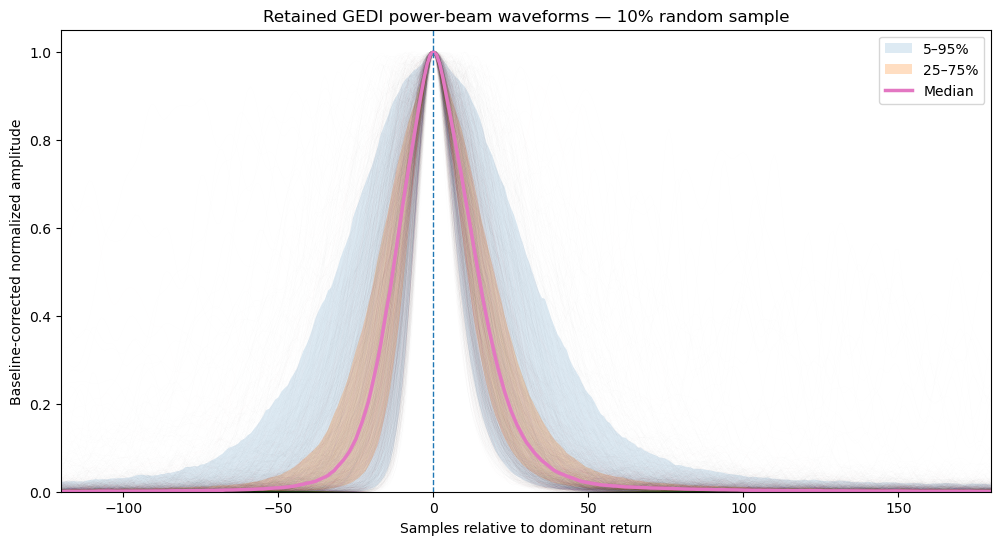

In [29]:
# =============================================================================
# All 10% sampled power-beam waveforms in one aligned plot
# =============================================================================

if len(aligned_waveforms) == 0:
    raise RuntimeError(
        "No aligned waveforms available."
    )

# Population summaries
wf_median = np.nanmedian(
    aligned_waveforms,
    axis=0,
)

wf_q25 = np.nanquantile(
    aligned_waveforms,
    0.25,
    axis=0,
)

wf_q75 = np.nanquantile(
    aligned_waveforms,
    0.75,
    axis=0,
)

wf_q05 = np.nanquantile(
    aligned_waveforms,
    0.05,
    axis=0,
)

wf_q95 = np.nanquantile(
    aligned_waveforms,
    0.95,
    axis=0,
)


fig, ax = plt.subplots(
    figsize=(12, 6)
)

# Every waveform
for wf in aligned_waveforms:

    ax.plot(
        relative_samples,
        wf,
        alpha=0.008,
        linewidth=0.35,
        rasterized=True,
    )

# 90% envelope
ax.fill_between(
    relative_samples,
    wf_q05,
    wf_q95,
    alpha=0.15,
    label="5–95%",
)

# IQR
ax.fill_between(
    relative_samples,
    wf_q25,
    wf_q75,
    alpha=0.25,
    label="25–75%",
)

# Median waveform
ax.plot(
    relative_samples,
    wf_median,
    linewidth=2.5,
    label="Median",
)

ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
)

ax.set_xlim(
    -ALIGN_LEFT,
    ALIGN_RIGHT,
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_xlabel(
    "Samples relative to dominant return"
)

ax.set_ylabel(
    "Baseline-corrected normalized amplitude"
)

ax.set_title(
    "Retained GEDI power-beam waveforms — "
    "10% random sample"
)

ax.legend()

plt.show()


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
rh50,1926.0,0.100431,1.475624,-1.98,-0.92,-0.510,-0.370,-0.22,-0.14,0.0000,0.370,0.9825,7.077500,29.629999
rh75,1926.0,1.787207,2.509989,0.41,0.70,0.740,0.780,0.93,1.27,1.7900,2.730,3.8400,11.410000,55.529999
rh90,1926.0,3.306511,3.208379,1.42,1.49,1.570,1.640,1.94,2.57,3.5475,5.155,6.7625,16.980001,66.470001
rh95,1926.0,4.207170,3.536117,1.83,1.94,2.020,2.130,2.54,3.38,4.6400,6.610,8.3575,19.339999,69.989998
rh98,1926.0,5.185182,3.846780,2.28,2.39,2.515,2.665,3.17,4.26,5.8575,8.055,10.2200,21.437500,71.709999
rh100,1926.0,6.748842,4.131589,3.06,3.36,3.590,3.770,4.42,5.76,7.7300,10.165,12.8450,23.597500,73.089996


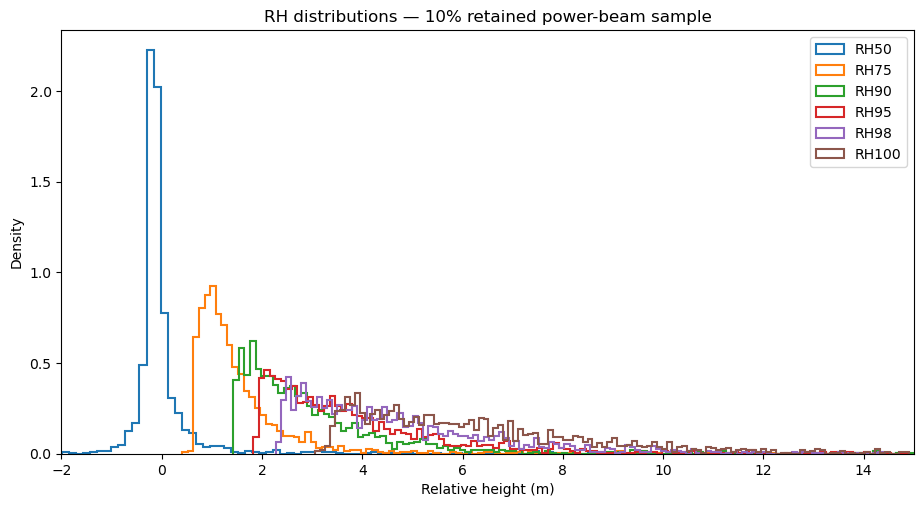

In [30]:
# =============================================================================
# RH distributions for retained power shots and the 10% waveform sample
# =============================================================================

RH_PLOT_COLS = [
    "rh50",
    "rh75",
    "rh90",
    "rh95",
    "rh98",
    "rh100",
]

RH_PLOT_COLS = [
    c for c in RH_PLOT_COLS
    if c in gedi_power_10.columns
]


# -------------------------------------------------------------------------
# Descriptive table
# -------------------------------------------------------------------------

rh_summary = (
    gedi_power_10[RH_PLOT_COLS]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)

display(rh_summary)


# -------------------------------------------------------------------------
# Overlay RH distributions
# -------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 5.5)
)

for col in RH_PLOT_COLS:

    x = (
        pd.to_numeric(
            gedi_power_10[col],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    # Focus on low-stature structure while retaining
    # the numerical tails in the summary table above.
    x = x[
        (x >= -2)
        & (x <= 15)
    ]

    ax.hist(
        x,
        bins=120,
        histtype="step",
        density=True,
        linewidth=1.5,
        label=col.upper(),
    )

ax.set_xlim(
    -2,
    15,
)

ax.set_xlabel(
    "Relative height (m)"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "RH distributions — 10% retained power-beam sample"
)

ax.legend()

plt.show()


In [31]:
# =============================================================================
# Check representativeness of the 10% power sample
# =============================================================================

rows = []

for col in RH_PLOT_COLS:

    for label, df in [
        ("all retained power", gedi_power),
        ("10% power sample", gedi_power_10),
    ]:

        x = pd.to_numeric(
            df[col],
            errors="coerce",
        ).dropna()

        rows.append({
            "subset": label,
            "metric": col,
            "n": len(x),
            "median": x.median(),
            "p25": x.quantile(0.25),
            "p75": x.quantile(0.75),
            "p95": x.quantile(0.95),
            "p99": x.quantile(0.99),
        })

display(
    pd.DataFrame(rows)
)


,subset,metric,n,median,p25,p75,p95,p99
0,all retained power,rh50,19265,-0.14,-0.22,0.0000,0.9300,6.950000
1,10% power sample,rh50,1926,-0.14,-0.22,0.0000,0.9825,7.077500
2,all retained power,rh75,19265,1.27,0.93,1.8300,3.9300,12.173600
3,10% power sample,rh75,1926,1.27,0.93,1.7900,3.8400,11.410000
4,all retained power,rh90,19265,2.58,1.94,3.5900,6.9800,17.143599
5,10% power sample,rh90,1926,2.57,1.94,3.5475,6.7625,16.980001
6,all retained power,rh95,19265,3.40,2.54,4.6800,8.8280,19.361600
7,10% power sample,rh95,1926,3.38,2.54,4.6400,8.3575,19.339999
8,all retained power,rh98,19265,4.27,3.18,5.8800,10.8960,21.370001
9,10% power sample,rh98,1926,4.26,3.17,5.8575,10.2200,21.437500


In [32]:
# =============================================================================
# Raw RX waveforms — peak aligned, NOT normalized
# =============================================================================

RAW_ALIGN_LEFT = 120
RAW_ALIGN_RIGHT = 180

raw_aligned_waveforms = []
raw_waveform_metadata = []

relative_samples_raw = np.arange(
    -RAW_ALIGN_LEFT,
    RAW_ALIGN_RIGHT + 1,
)

for _, row in gedi_power_10.iterrows():

    try:
        rx, _ = load_l1b_waveforms(
            l1b_path_for_key(
                row["granule_key"]
            ),
            row["beam"],
            row["shot_number"],
        )

    except Exception:
        continue

    if rx is None:
        continue

    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20:
        continue

    # Align using dominant raw return
    peak_idx = int(
        np.nanargmax(rx)
    )

    start = peak_idx - RAW_ALIGN_LEFT
    stop = peak_idx + RAW_ALIGN_RIGHT + 1

    if (
        start < 0
        or stop > len(rx)
    ):
        continue

    aligned = rx[start:stop]

    raw_aligned_waveforms.append(
        aligned
    )

    raw_waveform_metadata.append({
        "granule_key": row["granule_key"],
        "beam": row["beam"],
        "shot_number": row["shot_number"],
        "sensitivity": row["sensitivity"],
        "rh98": row["rh98"]
            if "rh98" in row.index
            else np.nan,
        "raw_peak": np.nanmax(rx),
        "raw_median": np.nanmedian(rx),
    })

raw_aligned_waveforms = np.asarray(
    raw_aligned_waveforms
)

raw_waveform_metadata = pd.DataFrame(
    raw_waveform_metadata
)

print(
    f"Aligned raw waveforms: "
    f"{len(raw_aligned_waveforms):,}"
)

print(
    "Matrix shape:",
    raw_aligned_waveforms.shape
)


Aligned raw waveforms: 1,926
Matrix shape: (1926, 301)


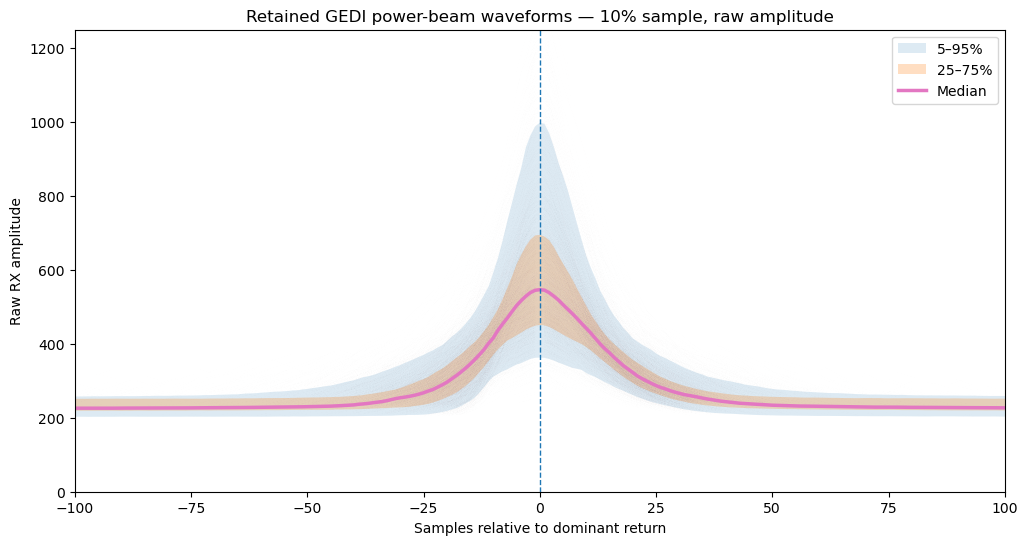

In [34]:
# =============================================================================
# Raw-amplitude waveform overlay
# =============================================================================

if len(raw_aligned_waveforms) == 0:
    raise RuntimeError(
        "No raw aligned waveforms available."
    )

raw_median = np.nanmedian(
    raw_aligned_waveforms,
    axis=0,
)

raw_q25 = np.nanquantile(
    raw_aligned_waveforms,
    0.25,
    axis=0,
)

raw_q75 = np.nanquantile(
    raw_aligned_waveforms,
    0.75,
    axis=0,
)

raw_q05 = np.nanquantile(
    raw_aligned_waveforms,
    0.05,
    axis=0,
)

raw_q95 = np.nanquantile(
    raw_aligned_waveforms,
    0.95,
    axis=0,
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for wf in raw_aligned_waveforms:

    ax.plot(
        relative_samples_raw,
        wf,
        alpha=0.004,
        linewidth=0.35,
        rasterized=True,
    )

ax.fill_between(
    relative_samples_raw,
    raw_q05,
    raw_q95,
    alpha=0.15,
    label="5–95%",
)

ax.fill_between(
    relative_samples_raw,
    raw_q25,
    raw_q75,
    alpha=0.25,
    label="25–75%",
)

ax.plot(
    relative_samples_raw,
    raw_median,
    linewidth=2.5,
    label="Median",
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Samples relative to dominant return"
)

ax.set_ylabel(
    "Raw RX amplitude"
)

ax.set_title(
    "Retained GEDI power-beam waveforms — "
    "10% sample, raw amplitude"
)
ax.set_ylim(0, 1250)
ax.set_xlim(-100, 100)
ax.legend()

plt.show()


In [35]:
# =============================================================================
# Baseline-corrected RX waveforms — peak aligned, NOT normalized
# =============================================================================

BASELINE_EDGE_FRACTION = 0.15

corrected_aligned_waveforms = []
corrected_waveform_metadata = []

for _, row in gedi_power_10.iterrows():

    try:
        rx, _ = load_l1b_waveforms(
            l1b_path_for_key(
                row["granule_key"]
            ),
            row["beam"],
            row["shot_number"],
        )

    except Exception:
        continue

    if rx is None:
        continue

    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20:
        continue

    n_edge = max(
        5,
        int(
            len(rx)
            * BASELINE_EDGE_FRACTION
        )
    )

    background_samples = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(
        background_samples
    )

    corrected = (
        rx - baseline
    )

    # Do NOT normalize amplitude.
    # Keep negative noise excursions too.
    peak_idx = int(
        np.nanargmax(corrected)
    )

    start = (
        peak_idx
        - RAW_ALIGN_LEFT
    )

    stop = (
        peak_idx
        + RAW_ALIGN_RIGHT
        + 1
    )

    if (
        start < 0
        or stop > len(corrected)
    ):
        continue

    aligned = corrected[start:stop]

    corrected_aligned_waveforms.append(
        aligned
    )

    corrected_waveform_metadata.append({
        "granule_key": row["granule_key"],
        "beam": row["beam"],
        "shot_number": row["shot_number"],
        "sensitivity": row["sensitivity"],
        "rh98": row["rh98"]
            if "rh98" in row.index
            else np.nan,
        "baseline": baseline,
        "peak_above_baseline":
            np.nanmax(corrected),
    })

corrected_aligned_waveforms = np.asarray(
    corrected_aligned_waveforms
)

corrected_waveform_metadata = pd.DataFrame(
    corrected_waveform_metadata
)

print(
    f"Baseline-corrected aligned waveforms: "
    f"{len(corrected_aligned_waveforms):,}"
)


Baseline-corrected aligned waveforms: 1,926


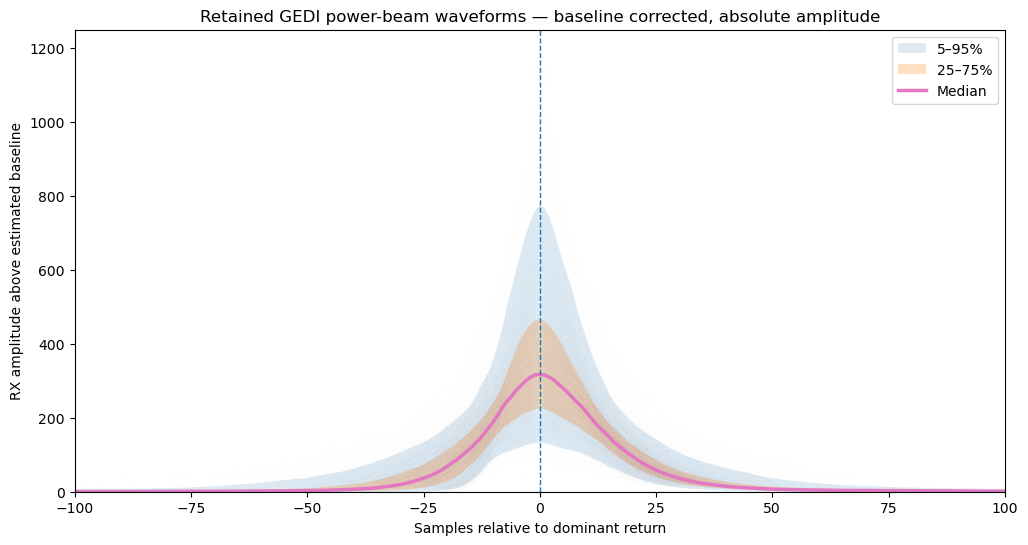

In [37]:
# =============================================================================
# Baseline-corrected absolute waveform overlay
# =============================================================================

corr_median = np.nanmedian(
    corrected_aligned_waveforms,
    axis=0,
)

corr_q25 = np.nanquantile(
    corrected_aligned_waveforms,
    0.25,
    axis=0,
)

corr_q75 = np.nanquantile(
    corrected_aligned_waveforms,
    0.75,
    axis=0,
)

corr_q05 = np.nanquantile(
    corrected_aligned_waveforms,
    0.05,
    axis=0,
)

corr_q95 = np.nanquantile(
    corrected_aligned_waveforms,
    0.95,
    axis=0,
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for wf in corrected_aligned_waveforms:

    ax.plot(
        relative_samples_raw,
        wf,
        alpha=0.004,
        linewidth=0.35,
        rasterized=True,
    )

ax.fill_between(
    relative_samples_raw,
    corr_q05,
    corr_q95,
    alpha=0.15,
    label="5–95%",
)

ax.fill_between(
    relative_samples_raw,
    corr_q25,
    corr_q75,
    alpha=0.25,
    label="25–75%",
)

ax.plot(
    relative_samples_raw,
    corr_median,
    linewidth=2.5,
    label="Median",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Samples relative to dominant return"
)

ax.set_ylabel(
    "RX amplitude above estimated baseline"
)

ax.set_title(
    "Retained GEDI power-beam waveforms — "
    "baseline corrected, absolute amplitude"
)
ax.set_ylim(0, 1250)
ax.set_xlim(-100, 100)
ax.legend()

plt.show()


In [38]:
# =============================================================================
# GEDI L2A detected-mode distribution in retained RCEW shots
# =============================================================================

mode_counts = (
    gedi_keep["num_detectedmodes"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("n")
    .to_frame()
)

mode_counts["percent"] = (
    100 * mode_counts["n"] / mode_counts["n"].sum()
)

display(mode_counts)

print(
    "Shots with >=2 GEDI-detected modes:",
    f"{(gedi_keep['num_detectedmodes'] >= 2).sum():,}"
)

print(
    "Percent with >=2 GEDI-detected modes:",
    f"{100 * (gedi_keep['num_detectedmodes'] >= 2).mean():.3f}%"
)


,n,percent
num_detectedmodes,,
1,26632,95.168668
2,953,3.405517
3,258,0.921955
4,95,0.339480
5,41,0.146512
6,3,0.010720
7,2,0.007147


Shots with >=2 GEDI-detected modes: 1,352
Percent with >=2 GEDI-detected modes: 4.831%


In [39]:
# =============================================================================
# Peak detection + constrained Gaussian mixture fitting
# =============================================================================

from scipy.signal import find_peaks, peak_widths
from scipy.optimize import least_squares

MAX_COMPONENTS = 7

BASELINE_EDGE_FRACTION = 0.15

# Peak detection controls
MIN_PEAK_DISTANCE = 3          # samples
MIN_PEAK_WIDTH = 1.0           # samples

# Require prominence relative to measured background noise.
PROMINENCE_NOISE_MULTIPLIER = 4.0

# Prevent pathological Gaussian collapse
MIN_SIGMA_SAMPLES = 0.75
MAX_SIGMA_SAMPLES = 100.0


def gaussian_sum(x, params):
    """
    params = [A1, mu1, sigma1, A2, mu2, sigma2, ...]
    """
    y = np.zeros_like(x, dtype=float)

    for k in range(len(params) // 3):

        A = params[3*k]
        mu = params[3*k + 1]
        sigma = params[3*k + 2]

        y += A * np.exp(
            -0.5 * ((x - mu) / sigma) ** 2
        )

    return y


def prepare_waveform(rx):
    """
    Estimate baseline and background noise.
    Preserve negative residuals for fitting diagnostics.
    """

    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20:
        return None

    n_edge = max(
        5,
        int(len(rx) * BASELINE_EDGE_FRACTION)
    )

    background = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(background)

    # Robust estimate of background noise
    mad = np.nanmedian(
        np.abs(background - baseline)
    )

    noise_sigma = 1.4826 * mad

    corrected = rx - baseline

    return {
        "corrected": corrected,
        "baseline": baseline,
        "noise_sigma": noise_sigma,
    }


def detect_waveform_peaks(corrected, noise_sigma):
    """
    Detect candidate waveform modes.

    Prominence threshold scales with empirical background noise.
    """

    if (
        not np.isfinite(noise_sigma)
        or noise_sigma <= 0
    ):
        noise_sigma = np.nanstd(corrected)

    prominence_threshold = (
        PROMINENCE_NOISE_MULTIPLIER
        * noise_sigma
    )

    peaks, properties = find_peaks(
        corrected,
        prominence=prominence_threshold,
        distance=MIN_PEAK_DISTANCE,
        width=MIN_PEAK_WIDTH,
    )

    if len(peaks) == 0:
        # Preserve at least the dominant valid return.
        peaks = np.array(
            [int(np.nanargmax(corrected))]
        )

        properties = {}

    # If >7 peaks are found, retain the seven most prominent.
    if len(peaks) > MAX_COMPONENTS:

        prominences = properties["prominences"]

        keep = np.argsort(
            prominences
        )[-MAX_COMPONENTS:]

        peaks = peaks[keep]

        # Restore height order
        peaks = np.sort(peaks)

    return peaks


def initialize_components(corrected, peaks):
    """
    Initialize A, mu, sigma from detected peaks.
    """

    x = np.arange(
        len(corrected),
        dtype=float,
    )

    # Estimate widths at half prominence.
    widths = peak_widths(
        corrected,
        peaks,
        rel_height=0.5,
    )[0]

    params = []

    for peak, width in zip(
        peaks,
        widths,
    ):

        A = max(
            corrected[peak],
            1e-6,
        )

        mu = float(peak)

        # Gaussian FWHM = 2.355 sigma
        sigma = max(
            float(width) / 2.35482,
            MIN_SIGMA_SAMPLES,
        )

        params.extend([
            A,
            mu,
            sigma,
        ])

    return np.asarray(
        params,
        dtype=float,
    )


def fit_waveform_gaussian_mixture(rx):
    """
    Detect waveform peaks and fit K Gaussians jointly.

    K is determined by peak detection, capped at 7.
    """

    prep = prepare_waveform(rx)

    if prep is None:
        return None

    corrected = prep["corrected"]
    baseline = prep["baseline"]
    noise_sigma = prep["noise_sigma"]

    x = np.arange(
        len(corrected),
        dtype=float,
    )

    peaks = detect_waveform_peaks(
        corrected,
        noise_sigma,
    )

    K = len(peaks)

    p0 = initialize_components(
        corrected,
        peaks,
    )

    lower = []
    upper = []

    for k in range(K):

        lower.extend([
            0.0,                  # amplitude
            0.0,                  # centroid
            MIN_SIGMA_SAMPLES,    # width
        ])

        upper.extend([
            np.inf,
            len(corrected) - 1,
            MAX_SIGMA_SAMPLES,
        ])

    lower = np.asarray(lower)
    upper = np.asarray(upper)

    def residuals(params):
        return (
            corrected
            - gaussian_sum(
                x,
                params,
            )
        )

    fit = least_squares(
        residuals,
        p0,
        bounds=(
            lower,
            upper,
        ),
        method="trf",
    )

    params = fit.x

    fitted = gaussian_sum(
        x,
        params,
    )

    residual = (
        corrected
        - fitted
    )

    ss_res = np.sum(
        residual ** 2
    )

    ss_tot = np.sum(
        (
            corrected
            - np.mean(corrected)
        ) ** 2
    )

    r2 = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    rmse = np.sqrt(
        np.mean(
            residual ** 2
        )
    )

    components = []

    for k in range(K):

        A = params[3*k]
        mu = params[3*k + 1]
        sigma = params[3*k + 2]

        area = (
            A
            * sigma
            * np.sqrt(2 * np.pi)
        )

        components.append({
            "component": k + 1,
            "amplitude": A,
            "mu_samples": mu,
            "sigma_samples": sigma,
            "fwhm_samples":
                2.35482 * sigma,
            "component_area": area,
        })

    return {
        "K_detected": K,
        "baseline": baseline,
        "noise_sigma": noise_sigma,
        "r2": r2,
        "rmse": rmse,
        "components": components,
    }


In [40]:
# =============================================================================
# Gaussian decomposition of ALL retained RCEW shots
# =============================================================================

from tqdm.auto import tqdm

fit_rows = []
component_rows = []

grouped = (
    gedi_keep
    .groupby(
        ["granule_key", "beam"],
        sort=False,
    )
)

for (
    granule_key,
    beam,
), group in tqdm(
    grouped,
    desc="RCEW Gaussian decomposition",
):

    l1b_path = l1b_path_for_key(
        granule_key
    )

    with h5py.File(
        l1b_path,
        "r",
    ) as h5:

        if beam not in h5:
            continue

        g = h5[beam]

        required = [
            "shot_number",
            "rxwaveform",
            "rx_sample_start_index",
            "rx_sample_count",
        ]

        if not all(
            name in g
            for name in required
        ):
            continue

        shots = np.asarray(
            g["shot_number"]
        )

        starts = np.asarray(
            g["rx_sample_start_index"]
        ).astype(np.int64)

        counts = np.asarray(
            g["rx_sample_count"]
        ).astype(np.int64)

        waveform_ds = g["rxwaveform"]

        shot_to_idx = {
            int(s): i
            for i, s in enumerate(shots)
        }

        for _, row in group.iterrows():

            shot_number = int(
                row["shot_number"]
            )

            i = shot_to_idx.get(
                shot_number
            )

            if i is None:
                continue

            start = (
                int(starts[i])
                - 1
            )

            count = int(
                counts[i]
            )

            stop = (
                start + count
            )

            if (
                start < 0
                or count <= 0
                or stop > len(waveform_ds)
            ):
                continue

            rx = np.asarray(
                waveform_ds[
                    start:stop
                ],
                dtype=float,
            )

            result = (
                fit_waveform_gaussian_mixture(
                    rx
                )
            )

            if result is None:
                continue

            fit_rows.append({
                "granule_key":
                    granule_key,

                "beam":
                    beam,

                "shot_number":
                    row["shot_number"],

                "GEDI_num_detectedmodes":
                    row.get(
                        "num_detectedmodes",
                        np.nan,
                    ),

                "K_detected":
                    result["K_detected"],

                "baseline":
                    result["baseline"],

                "noise_sigma":
                    result["noise_sigma"],

                "r2":
                    result["r2"],

                "rmse":
                    result["rmse"],

                "sensitivity":
                    row.get(
                        "sensitivity",
                        np.nan,
                    ),

                "rh98":
                    row.get(
                        "rh98",
                        np.nan,
                    ),
            })

            for comp in result[
                "components"
            ]:

                component_rows.append({
                    "granule_key":
                        granule_key,

                    "beam":
                        beam,

                    "shot_number":
                        row["shot_number"],

                    "K_detected":
                        result["K_detected"],

                    **comp,
                })


waveform_fits = pd.DataFrame(
    fit_rows
)

gaussian_components = pd.DataFrame(
    component_rows
)

print()
print("RCEW decomposition complete")
print("--------------------------")
print(
    f"Retained shots: "
    f"{len(gedi_keep):,}"
)
print(
    f"Successfully fitted: "
    f"{len(waveform_fits):,}"
)

display(
    waveform_fits.head()
)

display(
    gaussian_components.head()
)


RCEW Gaussian decomposition:   0%|          | 0/267 [00:00<?, ?it/s]


RCEW decomposition complete
--------------------------
Retained shots: 27,984
Successfully fitted: 27,984


,granule_key,beam,shot_number,GEDI_num_detectedmodes,K_detected,baseline,noise_sigma,r2,rmse,sensitivity,rh98
0,O02523_03_T02408_02,BEAM0000,25230000300133064,1,7,245.523842,1.622476,0.973973,3.841648,0.902793,3.10
1,O02523_03_T02408_02,BEAM0000,25230000300133065,1,7,245.881432,1.522495,0.978171,2.802983,0.908190,3.70
2,O02523_03_T02408_02,BEAM0000,25230000300133067,1,5,246.433281,1.625541,0.987922,2.306321,0.903782,3.55
3,O02523_03_T02408_02,BEAM0000,25230000300133068,1,1,246.312706,2.047409,0.971079,3.062082,0.918413,3.82
4,O02523_03_T02408_02,BEAM0000,25230000300133069,1,3,245.729141,1.837369,0.978166,1.938337,0.900159,6.06


,granule_key,beam,shot_number,K_detected,component,amplitude,mu_samples,sigma_samples,fwhm_samples,component_area
0,O02523_03_T02408_02,BEAM0000,25230000300133064,7,1,1.386228,86.945422,5.082702,11.968848,17.661159
1,O02523_03_T02408_02,BEAM0000,25230000300133064,7,2,4.612976,157.862500,2.026600,4.772278,23.433610
2,O02523_03_T02408_02,BEAM0000,25230000300133064,7,3,4.701798,218.741020,1.755363,4.133563,20.688107
3,O02523_03_T02408_02,BEAM0000,25230000300133064,7,4,152.913103,319.433546,10.666503,25.117695,4088.431320
4,O02523_03_T02408_02,BEAM0000,25230000300133064,7,5,4.491930,467.502279,4.952492,11.662227,55.763066


In [41]:
# =============================================================================
# Our Gaussian mode count versus GEDI L2A num_detectedmodes
# =============================================================================

comparison = pd.crosstab(
    waveform_fits[
        "GEDI_num_detectedmodes"
    ],
    waveform_fits[
        "K_detected"
    ],
    margins=True,
)

display(comparison)

print("\nOur fitted K distribution:")

display(
    waveform_fits[
        "K_detected"
    ]
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
    .assign(
        percent=lambda d:
            100
            * d["n"]
            / d["n"].sum()
    )
)


K_detected,1,2,3,4,5,6,7,All
GEDI_num_detectedmodes,,,,,,,,
1,1344,2939,4078,4256,3948,3242,6825,26632
2,10,37,67,131,107,122,479,953
3,3,2,4,17,21,37,174,258
4,0,1,2,1,8,12,71,95
5,0,0,1,0,0,2,38,41
6,0,0,0,1,0,0,2,3
7,0,0,0,0,0,0,2,2
All,1357,2979,4152,4406,4084,3415,7591,27984



Our fitted K distribution:


,n,percent
K_detected,,
1,1357,4.849200
2,2979,10.645369
3,4152,14.837050
4,4406,15.744711
5,4084,14.594054
6,3415,12.203402
7,7591,27.126215


In [42]:
# =============================================================================
# RCEW GAUSSIAN DECOMPOSITION — GEDI num_detectedmodes DEFINES K
#
# GEDI L2A num_detectedmodes determines the number of Gaussian components.
# L1B waveform structure is used ONLY to initialize component locations.
#
# Results are checkpointed by granule/beam so this cell can resume safely
# after a kernel restart.
# =============================================================================

import json
import h5py
import numpy as np
import pandas as pd

from pathlib import Path

from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_widths
from scipy.optimize import least_squares

from tqdm.auto import tqdm


# =============================================================================
# OUTPUT / CHECKPOINT PATHS
# =============================================================================

FIT_OUTPUT_DIR = (
    SUBSET_ROOT
    / "derived_waveform_fits"
)

FIT_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESOLVED_DIR = (
    FIT_OUTPUT_DIR
    / "GEDI_mode_constrained"
)

RESOLVED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIT_CHECKPOINT = (
    RESOLVED_DIR
    / "RCEW_waveform_fits_GEDI_K_checkpoint.pkl"
)

COMPONENT_CHECKPOINT = (
    RESOLVED_DIR
    / "RCEW_gaussian_components_GEDI_K_checkpoint.pkl"
)

PROGRESS_CHECKPOINT = (
    RESOLVED_DIR
    / "RCEW_GEDI_K_progress.json"
)

FINAL_FIT_PATH = (
    RESOLVED_DIR
    / "RCEW_waveform_fits_GEDI_K.pkl"
)

FINAL_COMPONENT_PATH = (
    RESOLVED_DIR
    / "RCEW_gaussian_components_GEDI_K.pkl"
)


# =============================================================================
# FIT SETTINGS
# =============================================================================

MAX_COMPONENTS = 7

BASELINE_EDGE_FRACTION = 0.15

# Used only to identify starting locations.
# The actual Gaussian fit uses the unsmoothed baseline-corrected waveform.
INITIALIZATION_SMOOTH_SIGMA = 1.5

MIN_INITIAL_PEAK_DISTANCE = 3

MIN_SIGMA_SAMPLES = 0.75
MAX_SIGMA_SAMPLES = 100.0


# =============================================================================
# GAUSSIAN MODEL
# =============================================================================

def gaussian_sum(x, params):

    y = np.zeros_like(
        x,
        dtype=float,
    )

    K = len(params) // 3

    for k in range(K):

        A = params[3*k]
        mu = params[3*k + 1]
        sigma = params[3*k + 2]

        y += (
            A
            * np.exp(
                -0.5
                * (
                    (x - mu)
                    / sigma
                ) ** 2
            )
        )

    return y


# =============================================================================
# BASELINE CORRECTION
# =============================================================================

def prepare_waveform_fixedK(rx):

    rx = np.asarray(
        rx,
        dtype=float,
    )

    if len(rx) < 20:
        return None

    if not np.isfinite(rx).all():
        return None

    n_edge = max(
        5,
        int(
            len(rx)
            * BASELINE_EDGE_FRACTION
        ),
    )

    background = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(
        background
    )

    corrected = (
        rx
        - baseline
    )

    mad = np.nanmedian(
        np.abs(
            background
            - baseline
        )
    )

    noise_sigma = (
        1.4826 * mad
    )

    return {
        "corrected":
            corrected,

        "baseline":
            baseline,

        "noise_sigma":
            noise_sigma,
    }


# =============================================================================
# INITIALIZE EXACTLY K COMPONENTS
# =============================================================================

def initialize_exactly_K_components(
    corrected,
    K,
):

    """
    Find candidate peaks only to initialize exactly K Gaussian components.

    K is NOT estimated here.
    K comes from GEDI L2A num_detectedmodes.
    """

    n = len(corrected)

    # -----------------------------------------------------------------
    # Smooth only for initialization.
    # -----------------------------------------------------------------

    smooth = gaussian_filter1d(
        corrected,
        sigma=INITIALIZATION_SMOOTH_SIGMA,
    )

    # -----------------------------------------------------------------
    # Candidate maxima.
    # -----------------------------------------------------------------

    candidate_peaks, props = find_peaks(
        smooth,
        distance=MIN_INITIAL_PEAK_DISTANCE,
        prominence=0,
    )

    selected = []

    # -----------------------------------------------------------------
    # Rank peaks by prominence.
    # -----------------------------------------------------------------

    if len(candidate_peaks) > 0:

        prominences = props.get(
            "prominences",
            smooth[candidate_peaks],
        )

        order = np.argsort(
            prominences
        )[::-1]

        selected = list(
            candidate_peaks[
                order[:K]
            ]
        )

    # -----------------------------------------------------------------
    # If fewer than K local maxima are found, add the strongest
    # remaining smoothed samples while enforcing minimum separation.
    #
    # This DOES NOT change K.
    # -----------------------------------------------------------------

    if len(selected) < K:

        ranked_samples = np.argsort(
            smooth
        )[::-1]

        for idx in ranked_samples:

            idx = int(idx)

            if any(
                abs(idx - p)
                < MIN_INITIAL_PEAK_DISTANCE
                for p in selected
            ):
                continue

            selected.append(
                idx
            )

            if len(selected) == K:
                break

    # -----------------------------------------------------------------
    # Defensive fallback.
    # -----------------------------------------------------------------

    if len(selected) < K:

        fallback = np.linspace(
            0,
            n - 1,
            K + 2,
        )[1:-1]

        for idx in fallback:

            idx = int(
                round(idx)
            )

            if idx not in selected:
                selected.append(
                    idx
                )

            if len(selected) == K:
                break

    selected = np.asarray(
        sorted(
            selected[:K]
        ),
        dtype=int,
    )

    # -----------------------------------------------------------------
    # Estimate initial FWHM -> sigma.
    # -----------------------------------------------------------------

    try:

        widths = peak_widths(
            smooth,
            selected,
            rel_height=0.5,
        )[0]

    except Exception:

        widths = np.full(
            K,
            5.0,
        )

    params = []

    for peak, width in zip(
        selected,
        widths,
    ):

        amplitude = max(
            corrected[peak],
            np.nanmax(corrected) * 0.01,
            1e-6,
        )

        sigma = max(
            float(width)
            / 2.35482,
            MIN_SIGMA_SAMPLES,
        )

        params.extend([
            amplitude,
            float(peak),
            sigma,
        ])

    return (
        np.asarray(
            params,
            dtype=float,
        ),
        selected,
    )


# =============================================================================
# CENTROID CONSTRAINTS
# =============================================================================

def centroid_bounds_from_initial_peaks(
    initial_peaks,
    waveform_length,
):

    """
    Give each Gaussian its own local centroid region.

    This reduces the tendency for multiple fitted components to collapse
    onto the same dominant return.
    """

    peaks = np.asarray(
        sorted(initial_peaks),
        dtype=float,
    )

    K = len(peaks)

    lower_mu = np.zeros(
        K,
        dtype=float,
    )

    upper_mu = np.full(
        K,
        waveform_length - 1,
        dtype=float,
    )

    if K > 1:

        mids = (
            peaks[:-1]
            + peaks[1:]
        ) / 2.0

        lower_mu[1:] = mids
        upper_mu[:-1] = mids

    return (
        lower_mu,
        upper_mu,
    )


# =============================================================================
# FIT EXACTLY K GAUSSIANS
# =============================================================================

def fit_waveform_GEDI_K(
    rx,
    K,
):

    if (
        not np.isfinite(K)
        or K < 1
    ):
        return None

    K = int(K)

    K = min(
        K,
        MAX_COMPONENTS,
    )

    prep = prepare_waveform_fixedK(
        rx
    )

    if prep is None:
        return None

    corrected = prep[
        "corrected"
    ]

    baseline = prep[
        "baseline"
    ]

    noise_sigma = prep[
        "noise_sigma"
    ]

    x = np.arange(
        len(corrected),
        dtype=float,
    )

    # -----------------------------------------------------------------
    # Initialize exactly K components.
    # -----------------------------------------------------------------

    p0, initial_peaks = (
        initialize_exactly_K_components(
            corrected,
            K,
        )
    )

    lower_mu, upper_mu = (
        centroid_bounds_from_initial_peaks(
            initial_peaks,
            len(corrected),
        )
    )

    lower = []
    upper = []

    for k in range(K):

        lower.extend([
            0.0,
            lower_mu[k],
            MIN_SIGMA_SAMPLES,
        ])

        upper.extend([
            np.inf,
            upper_mu[k],
            MAX_SIGMA_SAMPLES,
        ])

    lower = np.asarray(
        lower,
        dtype=float,
    )

    upper = np.asarray(
        upper,
        dtype=float,
    )

    eps = 1e-6

    p0 = np.maximum(
        p0,
        lower + eps,
    )

    p0 = np.minimum(
        p0,
        upper - eps,
    )

    # -----------------------------------------------------------------
    # Joint constrained least-squares fit.
    # -----------------------------------------------------------------

    def residuals(params):

        return (
            corrected
            - gaussian_sum(
                x,
                params,
            )
        )

    try:

        fit = least_squares(
            residuals,
            p0,
            bounds=(
                lower,
                upper,
            ),
            method="trf",
            max_nfev=1000,
        )

    except Exception:

        return None

    params = fit.x

    # -----------------------------------------------------------------
    # Sort components by fitted centroid.
    # -----------------------------------------------------------------

    component_params = []

    for k in range(K):

        component_params.append(
            (
                params[3*k],
                params[3*k + 1],
                params[3*k + 2],
            )
        )

    component_params = sorted(
        component_params,
        key=lambda z: z[1],
    )

    sorted_params = []

    for A, mu, sigma in component_params:

        sorted_params.extend([
            A,
            mu,
            sigma,
        ])

    sorted_params = np.asarray(
        sorted_params,
        dtype=float,
    )

    fitted = gaussian_sum(
        x,
        sorted_params,
    )

    residual = (
        corrected
        - fitted
    )

    # -----------------------------------------------------------------
    # Diagnostics.
    # -----------------------------------------------------------------

    ss_res = np.sum(
        residual ** 2
    )

    ss_tot = np.sum(
        (
            corrected
            - np.mean(corrected)
        ) ** 2
    )

    r2 = (
        1
        - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    rmse = np.sqrt(
        np.mean(
            residual ** 2
        )
    )

    components = []

    for k, (
        A,
        mu,
        sigma,
    ) in enumerate(
        component_params,
        start=1,
    ):

        area = (
            A
            * sigma
            * np.sqrt(
                2 * np.pi
            )
        )

        components.append({
            "component":
                k,

            "amplitude":
                A,

            "mu_samples":
                mu,

            "sigma_samples":
                sigma,

            "fwhm_samples":
                2.35482 * sigma,

            "component_area":
                area,
        })

    return {
        "K_GEDI":
            K,

        "baseline":
            baseline,

        "noise_sigma":
            noise_sigma,

        "r2":
            r2,

        "rmse":
            rmse,

        "components":
            components,
    }


# =============================================================================
# LOAD CHECKPOINTS IF PRESENT
# =============================================================================

if FIT_CHECKPOINT.exists():

    resolved_fit_rows = (
        pd.read_pickle(
            FIT_CHECKPOINT
        )
        .to_dict(
            orient="records"
        )
    )

    print(
        f"Loaded "
        f"{len(resolved_fit_rows):,} "
        f"checkpointed waveform fits."
    )

else:

    resolved_fit_rows = []


if COMPONENT_CHECKPOINT.exists():

    resolved_component_rows = (
        pd.read_pickle(
            COMPONENT_CHECKPOINT
        )
        .to_dict(
            orient="records"
        )
    )

    print(
        f"Loaded "
        f"{len(resolved_component_rows):,} "
        f"checkpointed Gaussian components."
    )

else:

    resolved_component_rows = []


if PROGRESS_CHECKPOINT.exists():

    with open(
        PROGRESS_CHECKPOINT,
        "r",
        encoding="utf-8",
    ) as f:

        progress = json.load(
            f
        )

    completed_groups = set(
        progress.get(
            "completed_groups",
            [],
        )
    )

else:

    completed_groups = set()


print(
    f"Completed granule/beam groups: "
    f"{len(completed_groups):,}"
)


# =============================================================================
# PROCESS RETAINED RCEW SHOTS
# =============================================================================

groups = list(
    gedi_keep.groupby(
        [
            "granule_key",
            "beam",
        ],
        sort=False,
    )
)

print(
    f"Total granule/beam groups: "
    f"{len(groups):,}"
)


for (
    granule_key,
    beam,
), group in tqdm(
    groups,
    desc="RCEW GEDI-K Gaussian decomposition",
):

    group_key = (
        f"{granule_key}::{beam}"
    )

    # -----------------------------------------------------------------
    # Safe resume.
    # -----------------------------------------------------------------

    if group_key in completed_groups:
        continue

    l1b_path = l1b_path_for_key(
        granule_key
    )

    try:

        with h5py.File(
            l1b_path,
            "r",
        ) as h5:

            if beam not in h5:
                continue

            g = h5[
                beam
            ]

            required = [
                "shot_number",
                "rxwaveform",
                "rx_sample_start_index",
                "rx_sample_count",
            ]

            if not all(
                name in g
                for name in required
            ):
                continue

            shots = np.asarray(
                g[
                    "shot_number"
                ]
            )

            starts = np.asarray(
                g[
                    "rx_sample_start_index"
                ]
            ).astype(
                np.int64
            )

            counts = np.asarray(
                g[
                    "rx_sample_count"
                ]
            ).astype(
                np.int64
            )

            waveform_ds = g[
                "rxwaveform"
            ]

            shot_to_idx = {
                int(s): i
                for i, s
                in enumerate(
                    shots
                )
            }

            # -------------------------------------------------------------
            # Process each retained shot.
            # -------------------------------------------------------------

            for _, row in group.iterrows():

                shot_number = int(
                    row[
                        "shot_number"
                    ]
                )

                K_gedi = row.get(
                    "num_detectedmodes",
                    np.nan,
                )

                if (
                    not np.isfinite(
                        K_gedi
                    )
                    or K_gedi < 1
                ):
                    continue

                i = shot_to_idx.get(
                    shot_number
                )

                if i is None:
                    continue

                start = (
                    int(
                        starts[i]
                    )
                    - 1
                )

                count = int(
                    counts[i]
                )

                stop = (
                    start
                    + count
                )

                if (
                    start < 0
                    or count <= 0
                    or stop > len(
                        waveform_ds
                    )
                ):
                    continue

                rx = np.asarray(
                    waveform_ds[
                        start:stop
                    ],
                    dtype=float,
                )

                result = (
                    fit_waveform_GEDI_K(
                        rx,
                        K_gedi,
                    )
                )

                if result is None:
                    continue

                # ---------------------------------------------------------
                # Footprint-level fit table
                # ---------------------------------------------------------

                resolved_fit_rows.append({
                    "granule_key":
                        granule_key,

                    "beam":
                        beam,

                    "shot_number":
                        shot_number,

                    "K_GEDI":
                        int(
                            K_gedi
                        ),

                    "baseline":
                        result[
                            "baseline"
                        ],

                    "noise_sigma":
                        result[
                            "noise_sigma"
                        ],

                    "r2":
                        result[
                            "r2"
                        ],

                    "rmse":
                        result[
                            "rmse"
                        ],

                    "sensitivity":
                        row.get(
                            "sensitivity",
                            np.nan,
                        ),

                    "rh50":
                        row.get(
                            "rh50",
                            np.nan,
                        ),

                    "rh90":
                        row.get(
                            "rh90",
                            np.nan,
                        ),

                    "rh95":
                        row.get(
                            "rh95",
                            np.nan,
                        ),

                    "rh98":
                        row.get(
                            "rh98",
                            np.nan,
                        ),

                    "rh100":
                        row.get(
                            "rh100",
                            np.nan,
                        ),

                    "elev_lowestmode":
                        row.get(
                            "elev_lowestmode",
                            np.nan,
                        ),

                    "digital_elevation_model":
                        row.get(
                            "digital_elevation_model",
                            np.nan,
                        ),

                    "lowestmode_minus_dem_m":
                        row.get(
                            "lowestmode_minus_dem_m",
                            np.nan,
                        ),

                    "solar_elevation":
                        row.get(
                            "solar_elevation",
                            np.nan,
                        ),
                })

                # ---------------------------------------------------------
                # Component-level table
                # ---------------------------------------------------------

                for comp in result[
                    "components"
                ]:

                    resolved_component_rows.append({
                        "granule_key":
                            granule_key,

                        "beam":
                            beam,

                        "shot_number":
                            shot_number,

                        "K_GEDI":
                            int(
                                K_gedi
                            ),

                        **comp,
                    })

    except Exception as exc:

        print()
        print(
            f"FAILED GROUP: "
            f"{group_key}"
        )

        print(
            repr(
                exc
            )
        )

        # Do not mark this group complete.
        continue

    # -----------------------------------------------------------------
    # Mark group complete.
    # -----------------------------------------------------------------

    completed_groups.add(
        group_key
    )

    # -----------------------------------------------------------------
    # CHECKPOINT AFTER EVERY GRANULE / BEAM GROUP
    # -----------------------------------------------------------------

    pd.DataFrame(
        resolved_fit_rows
    ).to_pickle(
        FIT_CHECKPOINT
    )

    pd.DataFrame(
        resolved_component_rows
    ).to_pickle(
        COMPONENT_CHECKPOINT
    )

    with open(
        PROGRESS_CHECKPOINT,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            {
                "completed_groups":
                    sorted(
                        completed_groups
                    ),

                "n_waveform_fits":
                    len(
                        resolved_fit_rows
                    ),

                "n_components":
                    len(
                        resolved_component_rows
                    ),
            },
            f,
            indent=2,
        )


# =============================================================================
# FINALIZE
# =============================================================================

waveform_fits_GEDI_K = pd.DataFrame(
    resolved_fit_rows
)

gaussian_components_GEDI_K = pd.DataFrame(
    resolved_component_rows
)

waveform_fits_GEDI_K.to_pickle(
    FINAL_FIT_PATH
)

gaussian_components_GEDI_K.to_pickle(
    FINAL_COMPONENT_PATH
)

print()
print(
    "RCEW GEDI-CONSTRAINED DECOMPOSITION COMPLETE"
)

print(
    "-------------------------------------------"
)

print(
    f"Retained shots: "
    f"{len(gedi_keep):,}"
)

print(
    f"Successful fits: "
    f"{len(waveform_fits_GEDI_K):,}"
)

print(
    f"Gaussian components: "
    f"{len(gaussian_components_GEDI_K):,}"
)

print()
print(
    "Final files:"
)

print(
    FINAL_FIT_PATH
)

print(
    FINAL_COMPONENT_PATH
)

print()
print(
    "GEDI K distribution in successful fits:"
)

display(
    waveform_fits_GEDI_K[
        "K_GEDI"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "n"
    )
    .to_frame()
    .assign(
        percent=lambda d:
            100
            * d["n"]
            / d["n"].sum()
    )
)

print()
print(
    "Fit quality:"
)

display(
    waveform_fits_GEDI_K[
        [
            "r2",
            "rmse",
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
)

Completed granule/beam groups: 0
Total granule/beam groups: 267


RCEW GEDI-K Gaussian decomposition:   0%|          | 0/267 [00:00<?, ?it/s]


RCEW GEDI-CONSTRAINED DECOMPOSITION COMPLETE
-------------------------------------------
Retained shots: 27,984
Successful fits: 27,984
Gaussian components: 29,929

Final files:
A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\RCEW_spatial_subset_h5\derived_waveform_fits\GEDI_mode_constrained\RCEW_waveform_fits_GEDI_K.pkl
A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\RCEW_spatial_subset_h5\derived_waveform_fits\GEDI_mode_constrained\RCEW_gaussian_components_GEDI_K.pkl

GEDI K distribution in successful fits:


,n,percent
K_GEDI,,
1,26632,95.168668
2,953,3.405517
3,258,0.921955
4,95,0.339480
5,41,0.146512
6,3,0.010720
7,2,0.007147



Fit quality:


,r2,rmse
count,27984.000000,27984.000000
mean,0.981396,5.110989
std,0.028229,2.603188
min,-0.142517,1.663338
1%,0.905104,2.128909
5%,0.951003,2.510949
25%,0.979817,3.416931
50%,0.987483,4.400570
75%,0.991823,5.975291
95%,0.995397,10.085692
